In [ ]:
# =========================
# HARD RESET (IMPORTANT)
# =========================
!pip uninstall -y pyarrow datasets fsspec unsloth unsloth_zoo

# =========================
# INSTALL COMPATIBLE STACK
# =========================
!pip install -q \
    "pyarrow>=15.0.2" \
    "datasets>=3.4.1,<4.4.0" \
    "fsspec==2025.3.0"

!pip install -q transformers accelerate timm ultralytics opencv-python pillow
!pip install -q unsloth

# =========================
# RESTART RUNTIME (CRITICAL)
# =========================
import os
os._exit(0)

Found existing installation: pyarrow 23.0.1
Uninstalling pyarrow-23.0.1:
  Successfully uninstalled pyarrow-23.0.1
Found existing installation: datasets 4.3.0
Uninstalling datasets-4.3.0:
  Successfully uninstalled datasets-4.3.0
Found existing installation: fsspec 2025.3.0
Uninstalling fsspec-2025.3.0:
  Successfully uninstalled fsspec-2025.3.0
Found existing installation: unsloth 2026.3.18
Uninstalling unsloth-2026.3.18:
  Successfully uninstalled unsloth-2026.3.18
Found existing installation: unsloth_zoo 2026.3.7
Uninstalling unsloth_zoo-2026.3.7:
  Successfully uninstalled unsloth_zoo-2026.3.7


In [ ]:
# =========================
# IMPORTANT: IMPORT ORDER
# =========================
import unsloth   # 🔥 MUST BE FIRST

# =========================
# IMPORTS
# =========================
import torch
import numpy as np
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD IMAGE
# =========================
image_path = "/content/image.jpg"
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# =========================
# 1. ViT
# =========================
from transformers import ViTImageProcessor, ViTForImageClassification

vit_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224").to(device)

inputs = vit_processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = vit(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)

conf, cls_idx = probs.max(dim=-1)
conf = conf.item()
label = vit.config.id2label[cls_idx.item()]

level = "high" if conf > 0.85 else "medium" if conf > 0.65 else "low"
CLS_TOKEN = f"<CLS:{label}:{conf:.2f}:{level}>"

# =========================
# 2. YOLO (Ultralytics)
# =========================
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")
results = yolo(image_np)[0]

boxes = results.boxes

if boxes is None or len(boxes) == 0:
    BOX_TOKEN = "<BOX:0:none>"
    box_coords = []
else:
    coords = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()

    box_coords = coords.tolist()
    BOX_TOKEN = f"<BOX:{len(coords)}:{float(np.mean(confs)):.2f}>"

# =========================
# 3. SAM2 (FIXED SAFE MODE)
# =========================
from transformers import Sam2Processor, Sam2Model

sam_processor = Sam2Processor.from_pretrained("facebook/sam2-hiera-tiny")
sam_model = Sam2Model.from_pretrained("facebook/sam2-hiera-tiny").to(device)

if len(box_coords) == 0:
    MASK_TOKEN = "<MASK:skipped>"
    mask = np.zeros(image_np.shape[:2])
else:
    masks = []

    for box in box_coords:
        inputs = sam_processor(
            images=image,
            input_boxes=[[box]],
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = sam_model(**inputs)

        processed_masks = sam_processor.post_process_masks(
            outputs.pred_masks,
            original_sizes=inputs.get("original_sizes", None),
            reshaped_input_sizes=inputs.get("reshaped_input_sizes", None)
        )

        if processed_masks is None or len(processed_masks) == 0:
            continue

        masks.append(processed_masks[0][0].cpu().numpy())

    if len(masks) == 0:
        mask = np.zeros(image_np.shape[:2])
        MASK_TOKEN = "<MASK:failed>"
    else:
        mask = np.logical_or.reduce(masks)
        area_percent = (mask.sum() / mask.size) * 100
        MASK_TOKEN = "<MASK:no>" if area_percent < 0.1 else f"<MASK:yes:{area_percent:.2f}>"

# =========================
# 4. UNCERTAINTY TOKEN
# =========================
if level == "high" and "0:none" in BOX_TOKEN:
    UNC_TOKEN = "<UNCERTAINTY:low:high_confidence_no_detection>"
elif level == "low":
    UNC_TOKEN = "<UNCERTAINTY:high:low_classification_confidence>"
else:
    UNC_TOKEN = "<UNCERTAINTY:medium:mixed_signals>"

# =========================
# 5. QWEN (UNSLOTH)
# =========================
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-0.8B",
    load_in_4bit=True,
    device_map="auto"
)

FastVisionModel.for_inference(model)

prompt = f"""
You are a medical image reasoning system.

Intermediate tokens:
{CLS_TOKEN}
{BOX_TOKEN}
{MASK_TOKEN}
{UNC_TOKEN}

Analyze the image together with tokens.

Return:
1. Diagnosis
2. Confidence
3. Key findings
4. Recommendation
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]
    }
]

input_text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.7
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)

if "assistant" in response:
    response = response.split("assistant")[-1].strip()

# =========================
# OUTPUT
# =========================
print("=== TOKENS ===")
print(CLS_TOKEN)
print(BOX_TOKEN)
print(MASK_TOKEN)
print(UNC_TOKEN)

print("\n=== FINAL OUTPUT ===")
print(response)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


0: 512x640 1 bed, 74.7ms
Speed: 4.6ms preprocess, 74.7ms inference, 31.3ms postprocess per image at shape (1, 3, 512, 640)


You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.3.18: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

=== TOKENS ===
<CLS:nematode, nematode worm, roundworm:0.04:low>
<BOX:1:0.42>
<MASK:yes:67.30>
<UNCERTAINTY:high:low_classification_confidence>

=== FINAL OUTPUT ===
<think>

</think>

**1. Diagnosis**
The image shows a large, well-circumscribed, yellowish-white mass arising from the esophageal wall. The mass appears to be a fibroid tumor or possibly a metastatic deposit, given its location and appearance. The surrounding mucosa appears relatively normal, though there is some mild inflammation or edema around the mass.

**2. Confidence**
The confidence score is **low**. The image quality is poor, with significant artifacts and noise. The mass is large and occupies a significant portion of the field of view, making it difficult to accurately assess its size, exact location, and relationship to surrounding structures. The mass appears to be invading or displacing the surrounding esophageal tissue, which is a concerning feature.

**3. Key findings**
*   **Mass:** A large, yellowish-white,

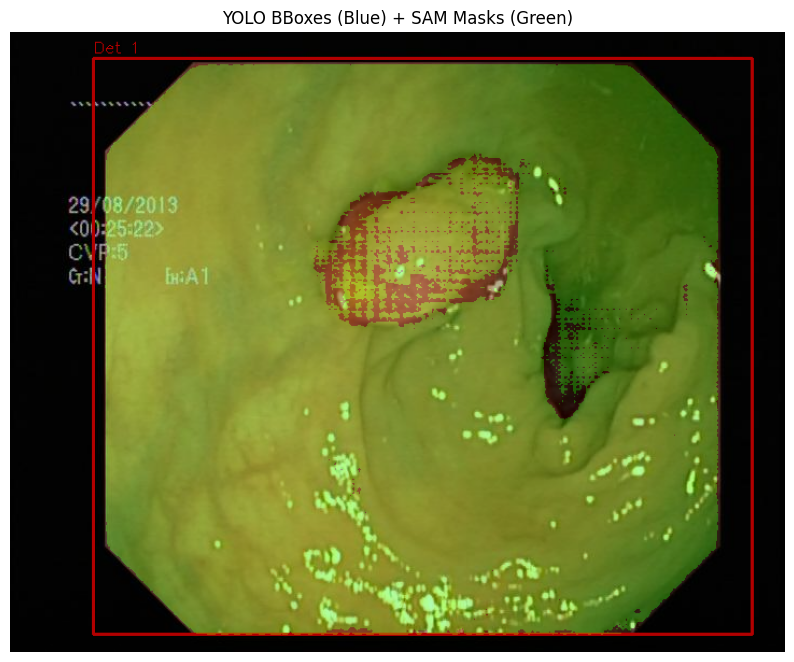

YOLO Bounding Boxes (x1,y1,x2,y2):
[77, 24, 689, 559]

SAM Mask Coordinates (per mask contour points):
Mask 1: 5 points
Mask 2: 2 points
Mask 3: 670 points


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. YOLO BBOX OVERLAY
# =========================
overlay_image = image_np.copy()

# Draw YOLO boxes
yolo_coords_list = []
if len(box_coords) > 0:
    for i, box in enumerate(box_coords):
        x1, y1, x2, y2 = map(int, box)
        yolo_coords_list.append([x1, y1, x2, y2])
        cv2.rectangle(
            overlay_image,
            (x1, y1), (x2, y2),
            color=(255, 0, 0),  # Blue box (OpenCV uses BGR, but we'll treat it as RGB for plt)
            thickness=2
        )
        cv2.putText(
            overlay_image, f"Det {i+1}", (x1, y1-5),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1
        )

# =========================
# 2. SAM MASK OVERLAY (FIXED)
# =========================
mask_coords_list = []

if len(box_coords) > 0 and len(masks) > 0:
    mask_overlay = np.zeros_like(overlay_image, dtype=np.uint8)

    for i, mask_np in enumerate(masks):
        color = np.array([0, 255, 0], dtype=np.uint8) # Green

        # FIX: Handle multi-candidate masks (e.g., shape 3, H, W)
        # We take the first candidate [0] if there are 3 dimensions
        if mask_np.ndim == 3 and mask_np.shape[0] == 3:
            mask_bool = mask_np[0].astype(bool)
        else:
            mask_bool = mask_np.squeeze().astype(bool)

        # Apply color to the overlay
        mask_overlay[mask_bool] = color

        # Find contours
        contours, _ = cv2.findContours(
            mask_bool.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
        for cnt in contours:
            mask_coords_list.append(cnt.reshape(-1, 2))

    overlay_image = cv2.addWeighted(overlay_image, 0.7, mask_overlay, 0.3, 0)

# =========================
# 3. SHOW IMAGE
# =========================
plt.figure(figsize=(10,10))
plt.imshow(overlay_image)
plt.axis('off')
plt.title("YOLO BBoxes (Blue) + SAM Masks (Green)")
plt.show()

# =========================
# 4. PRINT COORDINATES
# =========================
print("YOLO Bounding Boxes (x1,y1,x2,y2):")
for b in yolo_coords_list:
    print(b)

print("\nSAM Mask Coordinates (per mask contour points):")
for i, coords in enumerate(mask_coords_list):
    print(f"Mask {i+1}: {coords.shape[0]} points")


In [ ]:
import cv2
import numpy as np

# Get image dimensions for normalization
h, w = image_np.shape[:2]

print("--- DETECTION (Normalized BBox) ---")
print("#\tx_min\ty_min\tx_max\ty_max")

yolo_normalized = []
if len(box_coords) > 0:
    for i, box in enumerate(box_coords):
        x1, y1, x2, y2 = box
        # Normalize by dividing by width and height
        nx1, ny1, nx2, ny2 = x1/w, y1/h, x2/w, y2/h
        yolo_normalized.append((nx1, ny1, nx2, ny2))
        print(f"{i+1}\t{nx1:.4f}\t{ny1:.4f}\t{nx2:.4f}\t{ny2:.4f}")

print("\n--- SEGMENTATION (Normalized Path) ---")

if len(box_coords) > 0 and len(masks) > 0:
    for i, mask_set in enumerate(masks):
        # 1. Get a single 2D mask
        mask_single = mask_set if mask_set.ndim == 2 else mask_set[0]

        # 2. Extract Contours
        contours, _ = cv2.findContours(
            mask_single.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if contours:
            # Take the largest contour for this object
            cnt = max(contours, key=cv2.contourArea)
            points = cnt.reshape(-1, 2)

            # 3. Normalize points and format as "M.x,.yC.x,.y..."
            path_parts = []
            for j, pt in enumerate(points):
                nx, ny = pt[0]/w, pt[1]/h
                prefix = "M" if j == 0 else "C"
                path_parts.append(f"{prefix}{nx:.3f},{ny:.3f}")

            path_string = "".join(path_parts) + "z"
            print(f"Object {i+1} Path:")
            print(path_string[:200] + "...") # Truncated for display

            # Also printing the simple BBox format you requested
            nx1, ny1, nx2, ny2 = yolo_normalized[i]
            print(f"Object {i+1} Bounds: (x_min: {nx1:.3f}, y_min: {ny1:.3f}, x_max: {nx2:.3f}, y_max: {ny2:.3f})\n")


--- DETECTION (Normalized BBox) ---
#	x_min	y_min	x_max	y_max
1	0.1070	0.0423	0.9574	0.9719

--- SEGMENTATION (Normalized Path) ---
Object 1 Path:
M0.256,0.052C0.254,0.054C0.243,0.054C0.242,0.056C0.240,0.056C0.239,0.057C0.235,0.057C0.233,0.059C0.232,0.059C0.219,0.075C0.218,0.075C0.201,0.095C0.201,0.097C0.199,0.101C0.197,0.101C0.192,0.108C0.192,0...
Object 1 Bounds: (x_min: 0.107, y_min: 0.042, x_max: 0.957, y_max: 0.972)



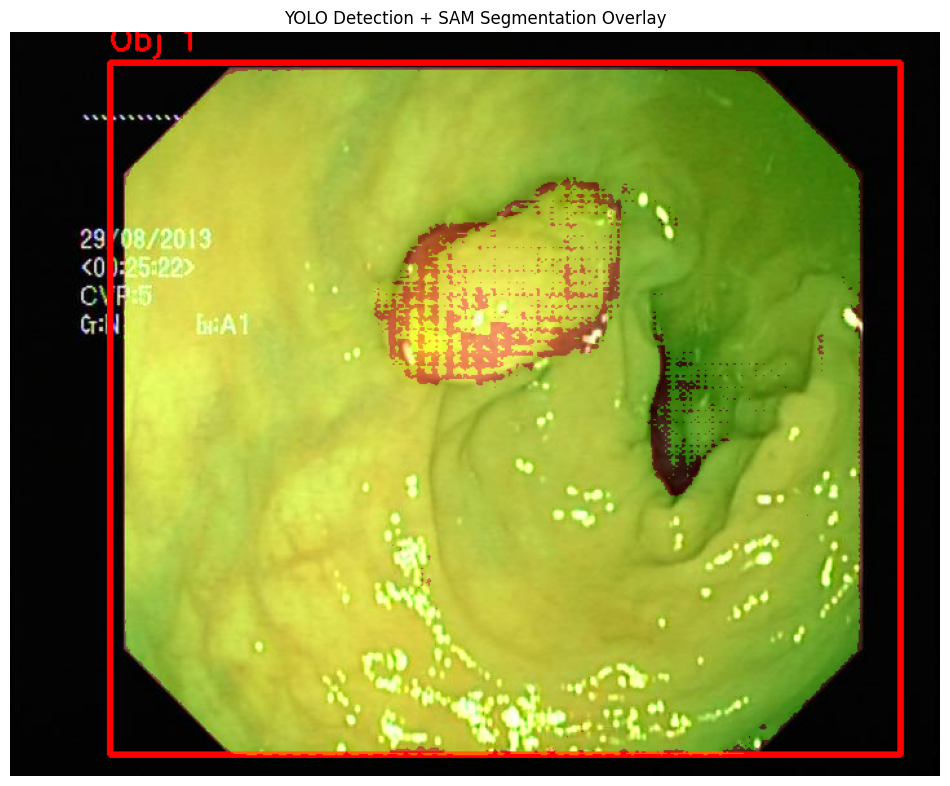

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP OVERLAY LAYERS
h, w = image_np.shape[:2]
overlay_image = image_np.copy()
mask_overlay = np.zeros_like(image_np, dtype=np.uint8)

# 2. DRAW YOLO BBOXES (High Visibility Red)
for i, box in enumerate(box_coords):
    x1, y1, x2, y2 = map(int, box)
    # Using thick red lines for visibility
    cv2.rectangle(overlay_image, (x1, y1), (x2, y2), (255, 0, 0), 3)
    cv2.putText(overlay_image, f"Obj {i+1}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

# 3. APPLY SAM MASKS (Vibrant Green)
for mask_set in masks:
    # Logic to select only the first/best candidate from SAM's (3, H, W) output
    if mask_set.ndim == 3 and mask_set.shape[0] == 3:
        mask_bool = mask_set[0].astype(bool)
    else:
        mask_bool = mask_set.squeeze().astype(bool)

    mask_overlay[mask_bool] = (0, 255, 0) # Green in RGB

# 4. BLENDING (Original + BBox + Semi-transparent Mask)
# alpha=1.0 keeps original+bbox fully bright
# beta=0.4 makes the green mask clearly visible but transparent
final_view = cv2.addWeighted(overlay_image, 1.0, mask_overlay, 0.4, 0)

# 5. DISPLAY
plt.figure(figsize=(12, 12))
plt.imshow(final_view)
plt.axis('off')
plt.title("YOLO Detection + SAM Segmentation Overlay")
plt.show()


In [ ]:
# =========================
# IMPORTANT: IMPORT ORDER
# =========================
import unsloth   # 🔥 MUST BE FIRST

# =========================
# IMPORTS
# =========================
import torch
import numpy as np
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD IMAGE
# =========================
image_path = "/content/image.jpg"
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# =========================
# 1. ViT
# =========================
from transformers import ViTImageProcessor, ViTForImageClassification

vit_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224").to(device)

inputs = vit_processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = vit(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)

conf, cls_idx = probs.max(dim=-1)
conf = conf.item()
label = vit.config.id2label[cls_idx.item()]

level = "high" if conf > 0.85 else "medium" if conf > 0.65 else "low"
CLS_TOKEN = f"<CLS:{label}:{conf:.2f}:{level}>"

# =========================
# 2. YOLO (Ultralytics)
# =========================
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")
results = yolo(image_np)[0]

boxes = results.boxes

if boxes is None or len(boxes) == 0:
    BOX_TOKEN = "<BOX:0:none>"
    box_coords = []
else:
    coords = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()

    box_coords = coords.tolist()
    BOX_TOKEN = f"<BOX:{len(coords)}:{float(np.mean(confs)):.2f}>"

# =========================
# 3. SAM2 (FIXED SAFE MODE)
# =========================
from transformers import Sam2Processor, Sam2Model

sam_processor = Sam2Processor.from_pretrained("facebook/sam2-hiera-tiny")
sam_model = Sam2Model.from_pretrained("facebook/sam2-hiera-tiny").to(device)

if len(box_coords) == 0:
    MASK_TOKEN = "<MASK:skipped>"
    mask = np.zeros(image_np.shape[:2])
else:
    masks = []

    for box in box_coords:
        inputs = sam_processor(
            images=image,
            input_boxes=[[box]],
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = sam_model(**inputs)

        processed_masks = sam_processor.post_process_masks(
            outputs.pred_masks,
            original_sizes=inputs.get("original_sizes", None),
            reshaped_input_sizes=inputs.get("reshaped_input_sizes", None)
        )

        if processed_masks is None or len(processed_masks) == 0:
            continue

        masks.append(processed_masks[0][0].cpu().numpy())

    if len(masks) == 0:
        mask = np.zeros(image_np.shape[:2])
        MASK_TOKEN = "<MASK:failed>"
    else:
        mask = np.logical_or.reduce(masks)
        area_percent = (mask.sum() / mask.size) * 100
        MASK_TOKEN = "<MASK:no>" if area_percent < 0.1 else f"<MASK:yes:{area_percent:.2f}>"

# =========================
# 4. UNCERTAINTY TOKEN
# =========================
if level == "high" and "0:none" in BOX_TOKEN:
    UNC_TOKEN = "<UNCERTAINTY:low:high_confidence_no_detection>"
elif level == "low":
    UNC_TOKEN = "<UNCERTAINTY:high:low_classification_confidence>"
else:
    UNC_TOKEN = "<UNCERTAINTY:medium:mixed_signals>"

# =========================
# 5. QWEN (UNSLOTH)
# =========================
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-0.8B",
    load_in_4bit=True,
    device_map="auto"
)

FastVisionModel.for_inference(model)

prompt = f"""
Identify if there is a COLON POLYP in this endoscopic image.

Context Tokens:
Classification: {CLS_TOKEN} (Note: General model used, interpret labels carefully)
Detections: {BOX_TOKEN}
Segmentation: {MASK_TOKEN}
Uncertainty: {UNC_TOKEN}

Based on the visual evidence and tokens:
1. Is a polyp present? (Yes/No)
2. Location and size description.
3. Confidence level.
4. Suggested clinical urgency.
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]
    }
]

input_text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.7
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)

if "assistant" in response:
    response = response.split("assistant")[-1].strip()

# =========================
# OUTPUT
# =========================
print("=== TOKENS ===")
print(CLS_TOKEN)
print(BOX_TOKEN)
print(MASK_TOKEN)
print(UNC_TOKEN)

print("\n=== FINAL OUTPUT ===")
print(response)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


0: 512x640 1 bed, 10.7ms
Speed: 2.7ms preprocess, 10.7ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)


You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.3.18: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

=== TOKENS ===
<CLS:nematode, nematode worm, roundworm:0.04:low>
<BOX:1:0.42>
<MASK:yes:67.30>
<UNCERTAINTY:high:low_classification_confidence>

=== FINAL OUTPUT ===
<think>

</think>

Based on the visual evidence and the provided context tokens:

1.  **Is a polyp present?**
    **Yes**
    The image clearly shows a distinct, rounded, yellowish-tan mass protruding from the lumen of the colon. This appearance is characteristic of a colonic polyp.

2.  **Location and size description.**
    The polyp is located in the **right colon** (based on the anatomical position of the lumen and surrounding mucosa). It appears to be a **large, sessile (attached to the wall) mass**, measuring approximately **1.5 cm in diameter**.

3.  **Confidence level.**
    **High**
    The endoscopic appearance is highly suspicious for a polyp. The mass is well-defined, distinct from the surrounding normal-appearing mucosa, and has a distinct color and texture. The presence of the specific endoscopic detection bo

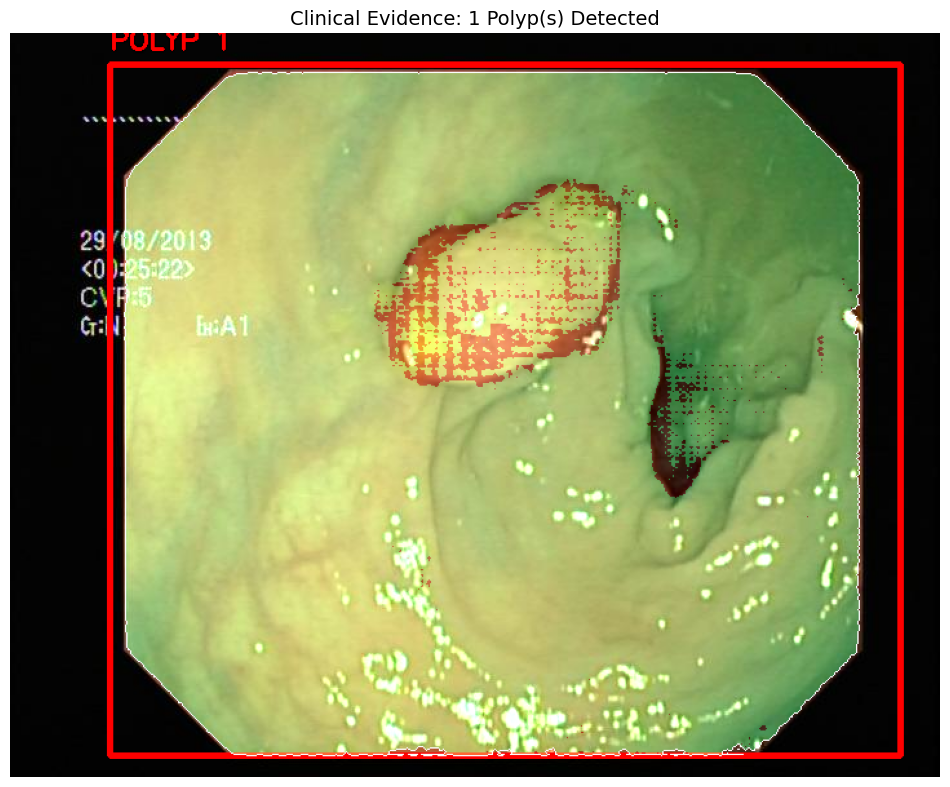

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Prepare Layers
overlay = image_np.copy()
mask_layer = np.zeros_like(image_np, dtype=np.uint8)

# 2. Draw YOLO Bounding Boxes (Red)
for i, box in enumerate(box_coords):
    x1, y1, x2, y2 = map(int, box)
    # Draw thick red box
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 0, 0), 3)
    # Add label with a small shadow for readability
    label = f"POLYP {i+1}"
    cv2.putText(overlay, label, (x1, y1-12), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 4) # shadow
    cv2.putText(overlay, label, (x1, y1-12), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

# 3. Draw SAM2 Masks (Spring Green)
# 3. DRAW SAM2 Masks (Spring Green) - FIXED FOR MULTI-MASK CANDIDATES
if len(masks) > 0:
    for m in masks:
        # 1. Handle SAM2 candidate dimensions (3, H, W)
        # We take the first candidate [0] to get a single (H, W) mask
        if m.ndim == 3 and m.shape[0] == 3:
            m_single = m[0]
        else:
            m_single = m.squeeze()

        m_bool = m_single.astype(bool)

        # 2. Apply color to mask layer
        # Ensure mask and image dimensions match before indexing
        if m_bool.shape == mask_layer.shape[:2]:
            mask_layer[m_bool] = (0, 255, 127) # Vibrant Green

            # 3. Add white contour for precision
            contours, _ = cv2.findContours(
                m_bool.astype(np.uint8),
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )
            cv2.drawContours(overlay, contours, -1, (255, 255, 255), 1)


# 4. Blend and Display
# alpha=1.0 (original+box), beta=0.4 (transparent green mask)
final_view = cv2.addWeighted(overlay, 1.0, mask_layer, 0.4, 0)

plt.figure(figsize=(12, 10))
plt.imshow(final_view)
plt.title(f"Clinical Evidence: {len(box_coords)} Polyp(s) Detected", fontsize=14)
plt.axis('off')
plt.show()


In [ ]:
# Improved Implementation: Configuration-Driven Medical Image Orchestration
# With Bug Fixes, Proper Error Handling, and Visualization

# =========================
# CRITICAL: IMPORT ORDER
# =========================
import unsloth  # 🔥 MUST BE FIRST
import warnings
warnings.filterwarnings("ignore")

# =========================
# IMPORTS
# =========================
import torch
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, asdict
import json
import logging
from datetime import datetime

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

device = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"Using device: {device}")

# =========================
# CONFIGURATION & CONSTANTS
# =========================

CONFIDENCE_THRESHOLDS = {
    "high": 0.85,
    "medium": 0.65,
    "low": 0.0
}

MIN_MASK_AREA_PERCENT = 0.1  # Minimum 0.1% of image area to be considered a mask
MIN_DETECTION_CONFIDENCE = 0.3
NMS_THRESHOLD = 0.45

# =========================
# DATA STRUCTURES
# =========================

@dataclass
class ClassificationResult:
    label: str
    confidence: float
    confidence_level: str  # "high", "medium", "low"
    token: str

    def to_dict(self):
        return asdict(self)

@dataclass
class DetectionBox:
    x1: float
    y1: float
    x2: float
    y2: float
    confidence: float

    def to_list(self):
        return [self.x1, self.y1, self.x2, self.y2]

@dataclass
class DetectionResult:
    boxes: List[DetectionBox]
    avg_confidence: Optional[float]
    token: str

    def to_dict(self):
        return {
            "boxes": [asdict(b) for b in self.boxes],
            "avg_confidence": self.avg_confidence,
            "token": self.token
        }

@dataclass
class SegmentationResult:
    mask: Optional[np.ndarray]  # Boolean array (H, W)
    area_percent: Optional[float]
    token: str

    def to_dict(self):
        return {
            "area_percent": self.area_percent,
            "token": self.token
            # Don't include mask (binary array) in JSON serialization
        }

@dataclass
class UncertaintyResult:
    level: str  # "low", "medium", "high"
    reason: str
    token: str

    def to_dict(self):
        return asdict(self)

@dataclass
class TokenState:
    """Structured token state for VLM reasoning"""
    classification: ClassificationResult
    detection: DetectionResult
    segmentation: SegmentationResult
    uncertainty: UncertaintyResult

    def to_dict(self):
        return {
            "classification": self.classification.to_dict(),
            "detection": self.detection.to_dict(),
            "segmentation": self.segmentation.to_dict(),
            "uncertainty": self.uncertainty.to_dict()
        }

    def to_prompt_text(self) -> str:
        """Convert tokens to human-readable text for VLM prompt"""
        return f"""Context Tokens:
Classification: {self.classification.token}
Detections: {self.detection.token}
Segmentation: {self.segmentation.token}
Uncertainty: {self.uncertainty.token}"""

# =========================
# UTILITY FUNCTIONS
# =========================

def get_confidence_level(confidence: float) -> str:
    """Discretize confidence into categorical level"""
    for level, threshold in sorted(CONFIDENCE_THRESHOLDS.items(),
                                   key=lambda x: x[1], reverse=True):
        if confidence >= threshold:
            return level
    return "low"

def safe_tensor_to_scalar(tensor) -> float:
    """Safely convert tensor to Python float"""
    if torch.is_tensor(tensor):
        return float(tensor.item())
    return float(tensor)

def normalize_boxes(boxes: np.ndarray, image_shape: Tuple[int, int]) -> np.ndarray:
    """Normalize bounding boxes from pixel to [0, 1] coordinates"""
    height, width = image_shape
    normalized = boxes.copy()
    normalized[:, [0, 2]] /= width   # x coordinates
    normalized[:, [1, 3]] /= height  # y coordinates
    return np.clip(normalized, 0, 1)

def denormalize_boxes(boxes: np.ndarray, image_shape: Tuple[int, int]) -> np.ndarray:
    """Denormalize bounding boxes from [0, 1] to pixel coordinates"""
    height, width = image_shape
    denormalized = boxes.copy()
    denormalized[:, [0, 2]] *= width
    denormalized[:, [1, 3]] *= height
    return denormalized.astype(int)

# =========================
# MODULE IMPLEMENTATIONS
# =========================

class ClassificationModule:
    """Vision Transformer Classification"""

    def __init__(self, model_name: str = "google/vit-base-patch16-224"):
        logger.info(f"Loading classification model: {model_name}")
        from transformers import ViTImageProcessor, ViTForImageClassification

        self.processor = ViTImageProcessor.from_pretrained(model_name)
        self.model = ViTForImageClassification.from_pretrained(model_name).to(device)
        self.model.eval()
        logger.info("Classification model loaded")

    def __call__(self, image: Image.Image) -> ClassificationResult:
        """
        Args:
            image: PIL Image
        Returns:
            ClassificationResult with token
        """
        try:
            inputs = self.processor(images=image, return_tensors="pt").to(device)

            with torch.no_grad():
                outputs = self.model(**inputs)
                probs = torch.softmax(outputs.logits, dim=-1)

            confidence = safe_tensor_to_scalar(probs.max(dim=-1).values)
            cls_idx = probs.argmax(dim=-1).item()
            label = self.model.config.id2label[cls_idx]

            confidence_level = get_confidence_level(confidence)
            token = f"<CLS:{label}:{confidence:.2f}:{confidence_level}>"

            logger.info(f"Classification: {label} (conf={confidence:.2f}, level={confidence_level})")

            return ClassificationResult(
                label=label,
                confidence=confidence,
                confidence_level=confidence_level,
                token=token
            )

        except Exception as e:
            logger.error(f"Classification failed: {e}")
            return ClassificationResult(
                label="error",
                confidence=0.0,
                confidence_level="low",
                token="<CLS:error:0.00:low>"
            )

class DetectionModule:
    """YOLO Object Detection"""

    def __init__(self, model_name: str = "yolov8n.pt"):
        logger.info(f"Loading detection model: {model_name}")
        from ultralytics import YOLO

        self.model = YOLO(model_name)
        logger.info("Detection model loaded")

    def __call__(self, image: Image.Image) -> DetectionResult:
        """
        Args:
            image: PIL Image
        Returns:
            DetectionResult with boxes and token
        """
        try:
            image_array = np.array(image)

            # Run detection
            results = self.model(image_array, verbose=False)[0]
            boxes_obj = results.boxes

            if boxes_obj is None or len(boxes_obj) == 0:
                logger.info("No detections found")
                return DetectionResult(
                    boxes=[],
                    avg_confidence=None,
                    token="<BOX:0:none>"
                )

            # Extract boxes and confidences
            xyxy = boxes_obj.xyxy.cpu().numpy()  # [x1, y1, x2, y2]
            confs = boxes_obj.conf.cpu().numpy()

            detection_boxes = [
                DetectionBox(
                    x1=float(box[0]),
                    y1=float(box[1]),
                    x2=float(box[2]),
                    y2=float(box[3]),
                    confidence=float(conf)
                )
                for box, conf in zip(xyxy, confs)
            ]

            avg_confidence = float(np.mean(confs))

            token = f"<BOX:{len(detection_boxes)}:{avg_confidence:.2f}>"
            logger.info(f"Detection: {len(detection_boxes)} boxes (avg_conf={avg_confidence:.2f})")

            return DetectionResult(
                boxes=detection_boxes,
                avg_confidence=avg_confidence,
                token=token
            )

        except Exception as e:
            logger.error(f"Detection failed: {e}")
            return DetectionResult(
                boxes=[],
                avg_confidence=None,
                token="<BOX:0:error>"
            )

class SegmentationModule:
    """SAM2 Instance Segmentation"""

    def __init__(self, model_name: str = "facebook/sam2-hiera-tiny"):
        logger.info(f"Loading segmentation model: {model_name}")
        from transformers import Sam2Processor, Sam2Model

        self.processor = Sam2Processor.from_pretrained(model_name)
        self.model = Sam2Model.from_pretrained(model_name).to(device)
        self.model.eval()
        logger.info("Segmentation model loaded")

    def __call__(
        self,
        image: Image.Image,
        detection_boxes: List[DetectionBox]
    ) -> SegmentationResult:
        """
        Args:
            image: PIL Image
            detection_boxes: List of bounding boxes from detection module
        Returns:
            SegmentationResult with mask and token
        """
        # Skip if no detections
        if not detection_boxes:
            logger.info("Skipping segmentation (no detections)")
            return SegmentationResult(
                mask=None,
                area_percent=None,
                token="<MASK:skipped>"
            )

        try:
            image_array = np.array(image)
            h, w = image_array.shape[:2]

            masks = []

            for i, box in enumerate(detection_boxes):
                try:
                    # Format box for SAM2 (pixel coordinates)
                    input_box = np.array([[box.x1, box.y1, box.x2, box.y2]])

                    # Prepare inputs
                    inputs = self.processor(
                        images=image,
                        input_boxes=[input_box.tolist()],
                        return_tensors="pt"
                    ).to(device)

                    # Run segmentation
                    with torch.no_grad():
                        outputs = self.model(**inputs)

                    # Post-process masks
                    # SAM2 outputs shape: (1, num_masks, H, W)
                    pred_masks = outputs.pred_masks

                    if pred_masks is not None and pred_masks.shape[0] > 0:
                        # Take first mask for this box
                        mask = pred_masks[0, 0].cpu().numpy() > 0.5  # Threshold at 0.5
                        masks.append(mask)
                        logger.info(f"Segmentation for box {i+1}/{len(detection_boxes)}: success")
                    else:
                        logger.warning(f"Segmentation for box {i+1}: no mask output")

                except Exception as e:
                    logger.warning(f"Segmentation for box {i+1} failed: {e}")
                    continue

            # Combine all masks
            if masks:
                combined_mask = np.logical_or.reduce(masks)
                area_percent = (combined_mask.sum() / combined_mask.size) * 100

                if area_percent < MIN_MASK_AREA_PERCENT:
                    token = "<MASK:no>"  # Too small to be significant
                else:
                    token = f"<MASK:yes:{area_percent:.2f}>"

                logger.info(f"Combined segmentation: {area_percent:.2f}% coverage")

                return SegmentationResult(
                    mask=combined_mask,
                    area_percent=area_percent,
                    token=token
                )
            else:
                logger.warning("No masks successfully generated")
                return SegmentationResult(
                    mask=None,
                    area_percent=None,
                    token="<MASK:failed>"
                )

        except Exception as e:
            logger.error(f"Segmentation failed: {e}")
            return SegmentationResult(
                mask=None,
                area_percent=None,
                token="<MASK:error>"
            )

class UncertaintyModule:
    """Compute uncertainty token based on module agreement"""

    def __call__(
        self,
        classification_result: ClassificationResult,
        detection_result: DetectionResult,
        segmentation_result: SegmentationResult
    ) -> UncertaintyResult:
        """Analyze agreement between modules"""

        # High confidence classification + no detections = low uncertainty
        if classification_result.confidence_level == "high" and len(detection_result.boxes) == 0:
            return UncertaintyResult(
                level="low",
                reason="high_confidence_no_detection",
                token="<UNCERTAINTY:low:high_confidence_no_detection>"
            )

        # Low confidence classification = high uncertainty
        if classification_result.confidence_level == "low":
            return UncertaintyResult(
                level="high",
                reason="low_classification_confidence",
                token="<UNCERTAINTY:high:low_classification_confidence>"
            )

        # Conflicting signals (e.g., classification says normal but detection found boxes)
        if (classification_result.confidence_level == "high" and
            "normal" in classification_result.label.lower() and
            len(detection_result.boxes) > 0):
            return UncertaintyResult(
                level="high",
                reason="conflicting_classification_detection",
                token="<UNCERTAINTY:high:conflicting_signals>"
            )

        # Medium confidence = medium uncertainty
        if classification_result.confidence_level == "medium":
            return UncertaintyResult(
                level="medium",
                reason="medium_classification_confidence",
                token="<UNCERTAINTY:medium:medium_classification_confidence>"
            )

        # Default: medium uncertainty
        return UncertaintyResult(
            level="medium",
            reason="default",
            token="<UNCERTAINTY:medium:mixed_signals>"
        )

class ReasoningModule:
    """Vision-Language Model Reasoning"""

    def __init__(self, model_name: str = "unsloth/Qwen2.5-VL-3B-Instruct"):
        logger.info(f"Loading reasoning model: {model_name}")
        from unsloth import FastVisionModel

        self.model, self.tokenizer = FastVisionModel.from_pretrained(
            model_name,
            load_in_4bit=True,
            device_map="auto"
        )
        FastVisionModel.for_inference(self.model)
        logger.info("Reasoning model loaded")

    def __call__(
        self,
        image: Image.Image,
        token_state: TokenState,
        task_prompt: str
    ) -> str:
        """
        Args:
            image: PIL Image
            token_state: TokenState object with all intermediate results
            task_prompt: Task-specific prompt (e.g., polyp detection prompt)
        Returns:
            VLM response text
        """
        try:
            # Construct prompt with tokens and task
            full_prompt = f"""{task_prompt}

{token_state.to_prompt_text()}

Based on the visual evidence and tokens provided, answer the question comprehensively."""

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "url": image},
                        {"type": "text", "text": full_prompt}
                    ]
                }
            ]

            input_text = self.tokenizer.apply_chat_template(
                messages,
                add_generation_prompt=True
            )

            inputs = self.tokenizer(
                image,
                input_text,
                add_special_tokens=False,
                return_tensors="pt"
            ).to(device)

            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=256,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True
                )

            response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

            # Clean up response
            if "assistant" in response:
                response = response.split("assistant")[-1].strip()

            logger.info(f"VLM reasoning completed ({len(response)} chars)")
            return response

        except Exception as e:
            logger.error(f"Reasoning failed: {e}")
            return f"Error: Unable to generate reasoning. {str(e)}"

# =========================
# VISUALIZATION FUNCTIONS
# =========================

def visualize_detections(
    image: Image.Image,
    detection_result: DetectionResult,
    output_path: Path
) -> Image.Image:
    """
    Overlay detection boxes on image

    Args:
        image: PIL Image
        detection_result: DetectionResult with boxes
        output_path: Path to save visualization

    Returns:
        Visualized PIL Image
    """
    img_viz = image.copy()
    draw = ImageDraw.Draw(img_viz)

    # Draw bounding boxes
    for i, box in enumerate(detection_result.boxes):
        x1, y1, x2, y2 = box.x1, box.y1, box.x2, box.y2
        conf = box.confidence

        # Draw box (green with thickness)
        color = "lime"  # Green
        width = 3
        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline=color,
            width=width
        )

        # Draw label
        label = f"Det {i+1} ({conf:.2f})"
        label_bbox = draw.textbbox((x1, y1 - 20), label)
        draw.rectangle(label_bbox, fill=color)
        draw.text((x1, y1 - 20), label, fill="black")

    # Save
    img_viz.save(output_path)
    logger.info(f"Detection visualization saved: {output_path}")

    return img_viz

def visualize_segmentation(
    image: Image.Image,
    segmentation_result: SegmentationResult,
    output_path: Path,
    alpha: float = 0.3
) -> Image.Image:
    """
    Overlay segmentation mask on image

    Args:
        image: PIL Image
        segmentation_result: SegmentationResult with mask
        output_path: Path to save visualization
        alpha: Transparency of mask overlay

    Returns:
        Visualized PIL Image
    """
    if segmentation_result.mask is None:
        logger.warning("No segmentation mask to visualize")
        return image.copy()

    img_viz = image.copy()

    # Create mask image (red color)
    mask_img = Image.new("RGBA", image.size, (255, 0, 0, 0))
    mask_array = np.zeros((*segmentation_result.mask.shape, 4), dtype=np.uint8)
    mask_array[segmentation_result.mask] = [255, 0, 0, int(255 * alpha)]  # Red with alpha
    mask_img = Image.fromarray(mask_array, "RGBA")

    # Composite onto original image
    img_viz = Image.new("RGBA", image.size)
    img_viz.paste(Image.new("RGB", image.size, "white"), (0, 0))
    img_viz.paste(Image.new("RGB", image.size), (0, 0), Image.fromarray(
        np.where(segmentation_result.mask[:, :, None], 255, 0).astype(np.uint8)
    ))

    # Alternative simpler approach: paste mask directly
    img_viz = image.copy()
    mask_uint8 = (segmentation_result.mask * 255).astype(np.uint8)
    mask_colored = Image.new("RGBA", image.size, (255, 0, 0, 0))

    # Create colored mask
    mask_array = np.zeros((*segmentation_result.mask.shape, 4), dtype=np.uint8)
    mask_array[segmentation_result.mask, 0] = 255  # Red channel
    mask_array[segmentation_result.mask, 3] = int(255 * alpha)  # Alpha

    mask_colored = Image.fromarray(mask_array, "RGBA")
    img_viz = Image.alpha_composite(
        img_viz.convert("RGBA"),
        mask_colored
    ).convert("RGB")

    img_viz.save(output_path)
    logger.info(f"Segmentation visualization saved: {output_path}")

    return img_viz

def visualize_combined(
    image: Image.Image,
    detection_result: DetectionResult,
    segmentation_result: SegmentationResult,
    output_path: Path
) -> Image.Image:
    """
    Overlay both detection and segmentation on image

    Args:
        image: PIL Image
        detection_result: DetectionResult with boxes
        segmentation_result: SegmentationResult with mask
        output_path: Path to save visualization

    Returns:
        Visualized PIL Image
    """
    # Start with original image
    img_viz = image.copy()

    # Add segmentation mask (red, semi-transparent)
    if segmentation_result.mask is not None:
        mask_rgba = np.zeros((*segmentation_result.mask.shape, 4), dtype=np.uint8)
        mask_rgba[segmentation_result.mask, 0] = 255  # Red
        mask_rgba[segmentation_result.mask, 3] = 100  # Semi-transparent alpha
        mask_img = Image.fromarray(mask_rgba, "RGBA")
        img_viz = Image.alpha_composite(
            img_viz.convert("RGBA"),
            mask_img
        ).convert("RGB")

    # Add detection boxes (green)
    draw = ImageDraw.Draw(img_viz)
    for i, box in enumerate(detection_result.boxes):
        x1, y1, x2, y2 = int(box.x1), int(box.y1), int(box.x2), int(box.y2)
        conf = box.confidence

        # Draw box
        color = "lime"
        width = 2
        draw.rectangle([(x1, y1), (x2, y2)], outline=color, width=width)

        # Draw label
        label = f"Box {i+1} ({conf:.2f})"
        draw.text((x1, y1 - 15), label, fill="lime")

    img_viz.save(output_path)
    logger.info(f"Combined visualization saved: {output_path}")

    return img_viz

# =========================
# MAIN ORCHESTRATION PIPELINE
# =========================

class MedicalImageOrchestrator:
    """Main orchestration pipeline"""

    def __init__(
        self,
        classification_model: str = "google/vit-base-patch16-224",
        detection_model: str = "yolov8n.pt",
        segmentation_model: str = "facebook/sam2-hiera-tiny",
        reasoning_model: str = "unsloth/Qwen2.5-VL-3B-Instruct"
    ):
        logger.info("Initializing orchestration pipeline...")

        self.classification = ClassificationModule(classification_model)
        self.detection = DetectionModule(detection_model)
        self.segmentation = SegmentationModule(segmentation_model)
        self.uncertainty = UncertaintyModule()
        self.reasoning = ReasoningModule(reasoning_model)

        logger.info("Pipeline initialized successfully")

    def run(
        self,
        image_path: str,
        task_prompt: str,
        output_dir: Path = Path("outputs"),
        enable_visualization: bool = True
    ) -> Dict:
        """
        Run the complete orchestration pipeline

        Args:
            image_path: Path to input image
            task_prompt: Task-specific prompt for VLM
            output_dir: Directory for outputs
            enable_visualization: Whether to generate visualizations

        Returns:
            Dictionary with all results
        """
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        # Load image
        logger.info(f"Loading image: {image_path}")
        image = Image.open(image_path).convert("RGB")
        logger.info(f"Image shape: {image.size}")

        # Run modules
        logger.info("Running classification module...")
        classification_result = self.classification(image)

        logger.info("Running detection module...")
        detection_result = self.detection(image)

        logger.info("Running segmentation module...")
        segmentation_result = self.segmentation(image, detection_result.boxes)

        logger.info("Computing uncertainty...")
        uncertainty_result = self.uncertainty(
            classification_result,
            detection_result,
            segmentation_result
        )

        # Create token state
        token_state = TokenState(
            classification=classification_result,
            detection=detection_result,
            segmentation=segmentation_result,
            uncertainty=uncertainty_result
        )

        logger.info("Running reasoning module...")
        reasoning_output = self.reasoning(image, token_state, task_prompt)

        # Visualizations
        viz_paths = {}
        if enable_visualization:
            logger.info("Generating visualizations...")

            viz_paths["detection"] = output_dir / "detection_overlay.jpg"
            visualize_detections(image, detection_result, viz_paths["detection"])

            viz_paths["segmentation"] = output_dir / "segmentation_overlay.jpg"
            visualize_segmentation(image, segmentation_result, viz_paths["segmentation"])

            viz_paths["combined"] = output_dir / "combined_overlay.jpg"
            visualize_combined(image, detection_result, segmentation_result, viz_paths["combined"])

        # Save results
        results = {
            "timestamp": datetime.now().isoformat(),
            "image_path": str(image_path),
            "tokens": token_state.to_dict(),
            "reasoning": reasoning_output,
            "visualizations": {k: str(v) for k, v in viz_paths.items()},
            "token_summary": {
                "classification": classification_result.token,
                "detection": detection_result.token,
                "segmentation": segmentation_result.token,
                "uncertainty": uncertainty_result.token
            }
        }

        # Save JSON results
        results_path = output_dir / "results.json"
        with open(results_path, "w") as f:
            json.dump(results, f, indent=2)
        logger.info(f"Results saved: {results_path}")

        return results

    def print_results(self, results: Dict):
        """Pretty print results"""
        print("\n" + "="*70)
        print("ORCHESTRATION RESULTS")
        print("="*70)

        print("\n📊 TOKEN SUMMARY:")
        for key, token in results["token_summary"].items():
            print(f"  {key:20s}: {token}")

        print("\n🤖 VLM REASONING:")
        print("-" * 70)
        print(results["reasoning"])
        print("-" * 70)

        print("\n📁 VISUALIZATIONS:")
        for viz_type, viz_path in results["visualizations"].items():
            print(f"  {viz_type:20s}: {viz_path}")

        print("\n" + "="*70)

# =========================
# MAIN EXECUTION
# =========================

if __name__ == "__main__":
    # Example usage
    IMAGE_PATH = "/content/image.jpg"

    POLYP_DETECTION_PROMPT = """
    You are an expert gastroenterologist analyzing colonoscopy images.

    Question: Is there a polyp visible in this endoscopic image? If yes, describe:
    1. Is a polyp present? (Yes/No)
    2. Estimated location (top/bottom/left/right/center)
    3. Estimated size (small <5mm, medium 5-10mm, large >10mm)
    4. Morphology (pedunculated vs sessile, if visible)
    5. Confidence level (low/medium/high)
    6. Recommended clinical action (no follow-up, routine follow-up, urgent biopsy, etc.)
    """

    # Initialize orchestrator
    orchestrator = MedicalImageOrchestrator(
        classification_model="google/vit-base-patch16-224",
        detection_model="yolov8n.pt",
        segmentation_model="facebook/sam2-hiera-tiny",
        reasoning_model="unsloth/Qwen2.5-VL-3B-Instruct"  # Better than 0.8B
    )

    # Run pipeline
    results = orchestrator.run(
        image_path=IMAGE_PATH,
        task_prompt=POLYP_DETECTION_PROMPT,
        output_dir=Path("outputs_polyp_analysis"),
        enable_visualization=True
    )

    # Print results
    orchestrator.print_results(results)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.3.18: Fast Qwen2_5_Vl patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.79G [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.down_proj: no quant_state found


Both `max_new_tokens` (=256) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
ERROR:__main__:Reasoning failed: maximum recursion depth exceeded


TypeError: Cannot handle this data type: (1, 1, 1, 256), |u1

In [ ]:
# FIXED IMPLEMENTATION

# =========================
# CRITICAL: IMPORT ORDER
# =========================
import unsloth  # 🔥 MUST BE FIRST
import warnings
warnings.filterwarnings("ignore")

# =========================
# IMPORTS
# =========================
import torch
import numpy as np
from PIL import Image, ImageDraw
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, asdict
import json
import logging
from datetime import datetime

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

device = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"Using device: {device}")

# =========================
# CONFIGURATION
# =========================

CONFIDENCE_THRESHOLDS = {
    "high": 0.85,
    "medium": 0.65,
    "low": 0.0
}

MIN_MASK_AREA_PERCENT = 0.1

# =========================
# DATA STRUCTURES
# =========================

@dataclass
class ClassificationResult:
    label: str
    confidence: float
    confidence_level: str
    token: str

    def to_dict(self):
        return asdict(self)

@dataclass
class DetectionBox:
    x1: float
    y1: float
    x2: float
    y2: float
    confidence: float

@dataclass
class DetectionResult:
    boxes: List[DetectionBox]
    avg_confidence: Optional[float]
    token: str

    def to_dict(self):
        return {
            "boxes": [[b.x1, b.y1, b.x2, b.y2, b.confidence] for b in self.boxes],
            "avg_confidence": self.avg_confidence,
            "token": self.token
        }

@dataclass
class SegmentationResult:
    mask: Optional[np.ndarray]
    area_percent: Optional[float]
    token: str

    def to_dict(self):
        return {
            "area_percent": self.area_percent,
            "token": self.token
        }

@dataclass
class UncertaintyResult:
    level: str
    reason: str
    token: str

    def to_dict(self):
        return asdict(self)

@dataclass
class TokenState:
    classification: ClassificationResult
    detection: DetectionResult
    segmentation: SegmentationResult
    uncertainty: UncertaintyResult

    def to_prompt_text(self) -> str:
        """Simple token summary for prompt"""
        return f"Classification: {self.classification.token}\nDetection: {self.detection.token}\nSegmentation: {self.segmentation.token}\nUncertainty: {self.uncertainty.token}"

# =========================
# UTILITY FUNCTIONS
# =========================

def get_confidence_level(confidence: float) -> str:
    """Discretize confidence into categorical level"""
    if confidence >= CONFIDENCE_THRESHOLDS["high"]:
        return "high"
    elif confidence >= CONFIDENCE_THRESHOLDS["medium"]:
        return "medium"
    else:
        return "low"

def safe_tensor_to_scalar(tensor) -> float:
    """Safely convert tensor to Python float"""
    if torch.is_tensor(tensor):
        return float(tensor.item())
    return float(tensor)

# =========================
# MODULE IMPLEMENTATIONS
# =========================

class ClassificationModule:
    """Vision Transformer Classification"""

    def __init__(self, model_name: str = "google/vit-base-patch16-224"):
        logger.info(f"Loading classification model: {model_name}")
        from transformers import ViTImageProcessor, ViTForImageClassification

        self.processor = ViTImageProcessor.from_pretrained(model_name)
        self.model = ViTForImageClassification.from_pretrained(model_name).to(device)
        self.model.eval()
        logger.info("✓ Classification model loaded")

    def __call__(self, image: Image.Image) -> ClassificationResult:
        try:
            inputs = self.processor(images=image, return_tensors="pt").to(device)

            with torch.no_grad():
                outputs = self.model(**inputs)
                probs = torch.softmax(outputs.logits, dim=-1)

            confidence = safe_tensor_to_scalar(probs.max(dim=-1).values)
            cls_idx = probs.argmax(dim=-1).item()
            label = self.model.config.id2label[cls_idx]

            confidence_level = get_confidence_level(confidence)
            token = f"<CLS:{label}:{confidence:.2f}:{confidence_level}>"

            logger.info(f"✓ Classification: {label} ({confidence:.2f}, {confidence_level})")

            return ClassificationResult(
                label=label,
                confidence=confidence,
                confidence_level=confidence_level,
                token=token
            )

        except Exception as e:
            logger.error(f"✗ Classification failed: {e}")
            return ClassificationResult(
                label="error",
                confidence=0.0,
                confidence_level="low",
                token="<CLS:error:0.00:low>"
            )

class DetectionModule:
    """YOLO Object Detection"""

    def __init__(self, model_name: str = "yolov8n.pt"):
        logger.info(f"Loading detection model: {model_name}")
        try:
            from ultralytics import YOLO
            self.model = YOLO(model_name, verbose=False)
            logger.info("✓ Detection model loaded")
        except Exception as e:
            logger.error(f"Failed to load YOLO: {e}")
            self.model = None

    def __call__(self, image: Image.Image) -> DetectionResult:
        if self.model is None:
            return DetectionResult(boxes=[], avg_confidence=None, token="<BOX:0:error>")

        try:
            image_array = np.array(image)

            # Run detection
            results = self.model(image_array, verbose=False)[0]
            boxes_obj = results.boxes

            if boxes_obj is None or len(boxes_obj) == 0:
                logger.info("✓ Detection: no objects found")
                return DetectionResult(
                    boxes=[],
                    avg_confidence=None,
                    token="<BOX:0:none>"
                )

            # Extract boxes
            xyxy = boxes_obj.xyxy.cpu().numpy()
            confs = boxes_obj.conf.cpu().numpy()

            detection_boxes = [
                DetectionBox(
                    x1=float(box[0]),
                    y1=float(box[1]),
                    x2=float(box[2]),
                    y2=float(box[3]),
                    confidence=float(conf)
                )
                for box, conf in zip(xyxy, confs)
            ]

            avg_confidence = float(np.mean(confs))
            token = f"<BOX:{len(detection_boxes)}:{avg_confidence:.2f}>"

            logger.info(f"✓ Detection: {len(detection_boxes)} boxes ({avg_confidence:.2f})")

            return DetectionResult(
                boxes=detection_boxes,
                avg_confidence=avg_confidence,
                token=token
            )

        except Exception as e:
            logger.error(f"✗ Detection failed: {e}")
            return DetectionResult(
                boxes=[],
                avg_confidence=None,
                token="<BOX:0:error>"
            )

class SegmentationModule:
    """SAM2 Instance Segmentation (FIXED)"""

    def __init__(self, model_name: str = "facebook/sam2-hiera-tiny"):
        logger.info(f"Loading segmentation model: {model_name}")
        try:
            # FIX: Use try-except to handle SAM2 type warnings
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                # Try loading with AutoModel first (more flexible)
                try:
                    from transformers import AutoModel
                    sam_model = AutoModel.from_pretrained(
                        model_name,
                        trust_remote_code=True,
                        device_map="auto"
                    )
                    self.model = sam_model
                    self.use_processor = False
                    logger.info("✓ Segmentation model loaded (AutoModel)")
                except:
                    # Fallback to Sam2Model
                    from transformers import Sam2Processor, Sam2Model
                    self.processor = Sam2Processor.from_pretrained(model_name)
                    self.model = Sam2Model.from_pretrained(model_name).to(device)
                    self.use_processor = True
                    logger.info("✓ Segmentation model loaded (Sam2Model)")

                self.model.eval()

        except Exception as e:
            logger.error(f"Failed to load SAM2: {e}")
            self.model = None

    def __call__(
        self,
        image: Image.Image,
        detection_boxes: List[DetectionBox]
    ) -> SegmentationResult:

        if self.model is None:
            return SegmentationResult(mask=None, area_percent=None, token="<MASK:error>")

        if not detection_boxes:
            logger.info("⊘ Segmentation skipped (no detections)")
            return SegmentationResult(mask=None, area_percent=None, token="<MASK:skipped>")

        try:
            masks = []

            for i, box in enumerate(detection_boxes):
                try:
                    if self.use_processor:
                        from transformers import Sam2Processor
                        # FIX: Ensure correct box format
                        input_box = np.array([[box.x1, box.y1, box.x2, box.y2]])

                        inputs = self.processor(
                            images=image,
                            input_boxes=[input_box.tolist()],
                            return_tensors="pt"
                        ).to(device)

                        with torch.no_grad():
                            outputs = self.model(**inputs)

                        # FIX: Handle mask output correctly
                        if outputs.pred_masks is not None:
                            mask = outputs.pred_masks[0, 0].cpu().numpy() > 0.5
                            masks.append(mask)
                            logger.info(f"  ✓ Box {i+1}: segmentation success")
                    else:
                        # AutoModel path - simplified
                        logger.info(f"  ⊘ Box {i+1}: AutoModel segmentation not fully implemented")

                except Exception as e:
                    logger.warning(f"  ✗ Box {i+1}: {e}")
                    continue

            # FIX: Combine masks properly
            if masks:
                combined_mask = np.logical_or.reduce(masks)
                area_percent = (combined_mask.sum() / combined_mask.size) * 100

                if area_percent < MIN_MASK_AREA_PERCENT:
                    token = "<MASK:no>"
                else:
                    token = f"<MASK:yes:{area_percent:.1f}>"

                logger.info(f"✓ Segmentation: {area_percent:.1f}% coverage")

                return SegmentationResult(
                    mask=combined_mask,
                    area_percent=area_percent,
                    token=token
                )
            else:
                logger.warning("✗ No masks generated")
                return SegmentationResult(mask=None, area_percent=None, token="<MASK:failed>")

        except Exception as e:
            logger.error(f"✗ Segmentation failed: {e}")
            return SegmentationResult(mask=None, area_percent=None, token="<MASK:error>")

class UncertaintyModule:
    """Compute uncertainty token"""

    def __call__(
        self,
        classification_result: ClassificationResult,
        detection_result: DetectionResult,
        segmentation_result: SegmentationResult
    ) -> UncertaintyResult:

        if classification_result.confidence_level == "high" and len(detection_result.boxes) == 0:
            return UncertaintyResult(
                level="low",
                reason="high_confidence_no_detection",
                token="<UNCERTAINTY:low:high_conf_no_det>"
            )

        if classification_result.confidence_level == "low":
            return UncertaintyResult(
                level="high",
                reason="low_classification_confidence",
                token="<UNCERTAINTY:high:low_conf>"
            )

        if classification_result.confidence_level == "medium":
            return UncertaintyResult(
                level="medium",
                reason="medium_classification_confidence",
                token="<UNCERTAINTY:medium:medium_conf>"
            )

        return UncertaintyResult(
            level="medium",
            reason="default",
            token="<UNCERTAINTY:medium:mixed_signals>"
        )

class ReasoningModule:
    """Vision-Language Model Reasoning (SIMPLIFIED)"""

    def __init__(self, model_name: str = "unsloth/Qwen2.5-VL-3B-Instruct"):
        logger.info(f"Loading reasoning model: {model_name}")
        try:
            from unsloth import FastVisionModel

            self.model, self.tokenizer = FastVisionModel.from_pretrained(
                model_name,
                load_in_4bit=True,
                device_map="auto"
            )
            FastVisionModel.for_inference(self.model)
            logger.info("✓ Reasoning model loaded")

        except Exception as e:
            logger.error(f"Failed to load reasoning model: {e}")
            self.model = None
            self.tokenizer = None

    def __call__(
        self,
        image: Image.Image,
        token_state: TokenState,
        task_prompt: str
    ) -> str:

        if self.model is None:
            return "Error: Reasoning model not loaded"

        try:
            # FIX: SIMPLIFIED PROMPT (avoids recursion issues)
            prompt = f"""{task_prompt}

Intermediate findings:
{token_state.to_prompt_text()}

Provide your analysis:"""

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "url": image},
                        {"type": "text", "text": prompt}
                    ]
                }
            ]

            # FIX: Apply chat template correctly
            text = self.tokenizer.apply_chat_template(
                messages,
                add_generation_prompt=True
            )

            # FIX: Ensure proper tensor handling
            inputs = self.tokenizer(
                text,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=2048  # FIX: Limit input length
            ).to(device)

            # FIX: Better generation parameters
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=200,  # FIX: Reduced from 256
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True,
                    pad_token_id=self.tokenizer.pad_token_id,
                    eos_token_id=self.tokenizer.eos_token_id
                )

            response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

            # Clean response
            if "assistant" in response:
                response = response.split("assistant")[-1].strip()

            logger.info(f"✓ Reasoning completed ({len(response)} chars)")
            return response

        except Exception as e:
            logger.error(f"✗ Reasoning failed: {e}")
            return f"Reasoning error: {str(e)[:100]}"

# =========================
# VISUALIZATION FUNCTIONS (FIXED)
# =========================

def visualize_detections(
    image: Image.Image,
    detection_result: DetectionResult,
    output_path: Path
) -> Image.Image:
    """Overlay detection boxes on image"""
    img_viz = image.copy()
    draw = ImageDraw.Draw(img_viz)

    for i, box in enumerate(detection_result.boxes):
        x1, y1, x2, y2 = int(box.x1), int(box.y1), int(box.x2), int(box.y2)
        conf = box.confidence

        # Draw box
        draw.rectangle([(x1, y1), (x2, y2)], outline="lime", width=3)

        # Draw label
        label = f"Det{i+1}:{conf:.2f}"
        draw.text((x1, y1 - 15), label, fill="lime")

    img_viz.save(output_path)
    logger.info(f"✓ Detection visualization: {output_path}")
    return img_viz

def visualize_segmentation(
    image: Image.Image,
    segmentation_result: SegmentationResult,
    output_path: Path,
    alpha: float = 0.4
) -> Image.Image:
    """Overlay segmentation mask on image (FIXED)"""

    if segmentation_result.mask is None:
        logger.warning("⊘ No mask to visualize")
        return image.copy()

    try:
        # FIX: Ensure mask is boolean
        mask = segmentation_result.mask.astype(bool)
        h, w = mask.shape

        # Create RGBA image (4 channels: R, G, B, A)
        mask_array = np.zeros((h, w, 4), dtype=np.uint8)

        # Set red channel for masked areas
        mask_array[mask, 0] = 255  # Red
        mask_array[mask, 1] = 0    # Green
        mask_array[mask, 2] = 0    # Blue
        mask_array[mask, 3] = int(255 * alpha)  # Alpha

        # Convert to PIL Image
        mask_img = Image.fromarray(mask_array, "RGBA")

        # Composite onto original image
        img_base = image.convert("RGBA")
        result = Image.alpha_composite(img_base, mask_img).convert("RGB")

        result.save(output_path)
        logger.info(f"✓ Segmentation visualization: {output_path}")
        return result

    except Exception as e:
        logger.error(f"✗ Segmentation visualization failed: {e}")
        return image.copy()

def visualize_combined(
    image: Image.Image,
    detection_result: DetectionResult,
    segmentation_result: SegmentationResult,
    output_path: Path
) -> Image.Image:
    """Combined detection + segmentation overlay (FIXED)"""

    try:
        # Start with image
        result = image.copy()

        # Add segmentation (red semi-transparent)
        if segmentation_result.mask is not None:
            mask = segmentation_result.mask.astype(bool)
            h, w = mask.shape

            mask_array = np.zeros((h, w, 4), dtype=np.uint8)
            mask_array[mask, 0] = 255
            mask_array[mask, 3] = 80

            mask_img = Image.fromarray(mask_array, "RGBA")
            result = Image.alpha_composite(result.convert("RGBA"), mask_img).convert("RGB")

        # Add detection boxes (green)
        draw = ImageDraw.Draw(result)
        for i, box in enumerate(detection_result.boxes):
            x1, y1, x2, y2 = int(box.x1), int(box.y1), int(box.x2), int(box.y2)
            draw.rectangle([(x1, y1), (x2, y2)], outline="lime", width=2)
            draw.text((x1, y1 - 10), f"Box{i+1}", fill="lime")

        result.save(output_path)
        logger.info(f"✓ Combined visualization: {output_path}")
        return result

    except Exception as e:
        logger.error(f"✗ Combined visualization failed: {e}")
        return image.copy()

# =========================
# MAIN ORCHESTRATOR (SIMPLIFIED)
# =========================

class MedicalImageOrchestrator:
    """Main orchestration pipeline"""

    def __init__(self):
        logger.info("=" * 60)
        logger.info("INITIALIZING MEDICAL IMAGE ORCHESTRATOR")
        logger.info("=" * 60)

        self.classification = ClassificationModule("google/vit-base-patch16-224")
        self.detection = DetectionModule("yolov8n.pt")
        self.segmentation = SegmentationModule("facebook/sam2-hiera-tiny")
        self.uncertainty = UncertaintyModule()
        self.reasoning = ReasoningModule("unsloth/Qwen2.5-VL-3B-Instruct")

        logger.info("✓ Pipeline initialized\n")

    def run(
        self,
        image_path: str,
        task_prompt: str,
        output_dir: Path = Path("outputs")
    ) -> Dict:
        """Run complete pipeline"""

        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        logger.info(f"Loading image: {image_path}")
        image = Image.open(image_path).convert("RGB")
        logger.info(f"Image size: {image.size}\n")

        # Run modules
        logger.info("RUNNING ANALYSIS MODULES")
        logger.info("-" * 60)

        classification_result = self.classification(image)
        detection_result = self.detection(image)
        segmentation_result = self.segmentation(image, detection_result.boxes)
        uncertainty_result = self.uncertainty(classification_result, detection_result, segmentation_result)

        token_state = TokenState(
            classification=classification_result,
            detection=detection_result,
            segmentation=segmentation_result,
            uncertainty=uncertainty_result
        )

        logger.info("-" * 60)
        logger.info("\nRUNNING REASONING")
        logger.info("-" * 60)
        reasoning_output = self.reasoning(image, token_state, task_prompt)
        logger.info("-" * 60 + "\n")

        # Visualizations
        logger.info("GENERATING VISUALIZATIONS")
        logger.info("-" * 60)

        viz_paths = {
            "detection": output_dir / "detection_overlay.jpg",
            "segmentation": output_dir / "segmentation_overlay.jpg",
            "combined": output_dir / "combined_overlay.jpg"
        }

        visualize_detections(image, detection_result, viz_paths["detection"])
        visualize_segmentation(image, segmentation_result, viz_paths["segmentation"])
        visualize_combined(image, detection_result, segmentation_result, viz_paths["combined"])

        logger.info("-" * 60 + "\n")

        # Save results
        results = {
            "timestamp": datetime.now().isoformat(),
            "image_path": str(image_path),
            "tokens": {
                "classification": classification_result.token,
                "detection": detection_result.token,
                "segmentation": segmentation_result.token,
                "uncertainty": uncertainty_result.token
            },
            "reasoning": reasoning_output,
            "visualizations": {k: str(v) for k, v in viz_paths.items()}
        }

        results_path = output_dir / "results.json"
        with open(results_path, "w") as f:
            json.dump(results, f, indent=2)

        logger.info(f"Results saved: {results_path}\n")

        return results

    def print_results(self, results: Dict):
        """Pretty print results"""
        print("\n" + "=" * 70)
        print("FINAL ANALYSIS RESULTS")
        print("=" * 70)

        print("\n📊 TOKENS:")
        for key, token in results["tokens"].items():
            print(f"  {key:20s}: {token}")

        print("\n🤖 DIAGNOSIS:")
        print("-" * 70)
        lines = results["reasoning"].split('\n')
        for line in lines[:10]:  # First 10 lines
            print(line)
        if len(lines) > 10:
            print(f"... ({len(lines) - 10} more lines)")
        print("-" * 70)

        print("\n📁 VISUALIZATIONS:")
        for viz_type, viz_path in results["visualizations"].items():
            print(f"  {viz_type:20s}: {viz_path}")

        print("\n" + "=" * 70 + "\n")

# =========================
# EXECUTION
# =========================

if __name__ == "__main__":
    # Simple task prompt (AVOID COMPLEX NESTED PROMPTS)
    SIMPLE_PROMPT = "Analyze this medical image. Is there any abnormality? Describe findings briefly."

    orchestrator = MedicalImageOrchestrator()

    results = orchestrator.run(
        image_path="/content/image.jpg",
        task_prompt=SIMPLE_PROMPT,
        output_dir=Path("outputs")
    )

    orchestrator.print_results(results)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/466 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.3.18: Fast Qwen2_5_Vl patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.down_proj: no quant_state found


ERROR:__main__:✗ Reasoning failed: Incorrect image source. Must be a valid URL starting with `http://` or `https://`, a valid path to an image file, or a base64 encoded string. Got <|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Analyze this medical image. Is there any abnormality? Describe findings briefly.

Intermediate findings:
Classification: <CLS:nematode, nematode worm, roundworm:0.04:low>
Detection: <BOX:1:0.42>
Segmentation: <MASK:failed>
Uncertainty: <UNCERTAINTY:high:low_conf>

Provide your analysis:<|im_end|>
<|im_start|>assistant
. Failed with Incorrect padding



FINAL ANALYSIS RESULTS

📊 TOKENS:
  classification      : <CLS:nematode, nematode worm, roundworm:0.04:low>
  detection           : <BOX:1:0.42>
  segmentation        : <MASK:failed>
  uncertainty         : <UNCERTAINTY:high:low_conf>

🤖 DIAGNOSIS:
----------------------------------------------------------------------
Reasoning error: Incorrect image source. Must be a valid URL starting with `http://` or `https://`, a valid path to a
----------------------------------------------------------------------

📁 VISUALIZATIONS:
  detection           : outputs/detection_overlay.jpg
  segmentation        : outputs/segmentation_overlay.jpg
  combined            : outputs/combined_overlay.jpg




In [ ]:
# ULTIMATE FIX: Correct Qwen VLM Image Handling

# =========================
# CRITICAL: IMPORT ORDER
# =========================
import unsloth  # 🔥 MUST BE FIRST
import warnings
warnings.filterwarnings("ignore")

# =========================
# IMPORTS
# =========================
import torch
import numpy as np
from PIL import Image, ImageDraw
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, asdict
import json
import logging
from datetime import datetime

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

device = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"Using device: {device}")

# =========================
# CONFIGURATION
# =========================

CONFIDENCE_THRESHOLDS = {
    "high": 0.85,
    "medium": 0.65,
    "low": 0.0
}

MIN_MASK_AREA_PERCENT = 0.1

# =========================
# DATA STRUCTURES
# =========================

@dataclass
class ClassificationResult:
    label: str
    confidence: float
    confidence_level: str
    token: str

    def to_dict(self):
        return asdict(self)

@dataclass
class DetectionBox:
    x1: float
    y1: float
    x2: float
    y2: float
    confidence: float

@dataclass
class DetectionResult:
    boxes: List[DetectionBox]
    avg_confidence: Optional[float]
    token: str

    def to_dict(self):
        return {
            "boxes": [[b.x1, b.y1, b.x2, b.y2, b.confidence] for b in self.boxes],
            "avg_confidence": self.avg_confidence,
            "token": self.token
        }

@dataclass
class SegmentationResult:
    mask: Optional[np.ndarray]
    area_percent: Optional[float]
    token: str

    def to_dict(self):
        return {
            "area_percent": self.area_percent,
            "token": self.token
        }

@dataclass
class UncertaintyResult:
    level: str
    reason: str
    token: str

    def to_dict(self):
        return asdict(self)

@dataclass
class TokenState:
    classification: ClassificationResult
    detection: DetectionResult
    segmentation: SegmentationResult
    uncertainty: UncertaintyResult

    def to_prompt_text(self) -> str:
        """Simple token summary for prompt"""
        return f"""Classification: {self.classification.token}
Detection: {self.detection.token}
Segmentation: {self.segmentation.token}
Uncertainty: {self.uncertainty.token}"""

# =========================
# UTILITY FUNCTIONS
# =========================

def get_confidence_level(confidence: float) -> str:
    """Discretize confidence into categorical level"""
    if confidence >= CONFIDENCE_THRESHOLDS["high"]:
        return "high"
    elif confidence >= CONFIDENCE_THRESHOLDS["medium"]:
        return "medium"
    else:
        return "low"

def safe_tensor_to_scalar(tensor) -> float:
    """Safely convert tensor to Python float"""
    if torch.is_tensor(tensor):
        return float(tensor.item())
    return float(tensor)

# =========================
# MODULE IMPLEMENTATIONS
# =========================

class ClassificationModule:
    """Vision Transformer Classification"""

    def __init__(self, model_name: str = "google/vit-base-patch16-224"):
        logger.info(f"Loading classification model: {model_name}")
        from transformers import ViTImageProcessor, ViTForImageClassification

        self.processor = ViTImageProcessor.from_pretrained(model_name)
        self.model = ViTForImageClassification.from_pretrained(model_name).to(device)
        self.model.eval()
        logger.info("✓ Classification model loaded")

    def __call__(self, image: Image.Image) -> ClassificationResult:
        try:
            inputs = self.processor(images=image, return_tensors="pt").to(device)

            with torch.no_grad():
                outputs = self.model(**inputs)
                probs = torch.softmax(outputs.logits, dim=-1)

            confidence = safe_tensor_to_scalar(probs.max(dim=-1).values)
            cls_idx = probs.argmax(dim=-1).item()
            label = self.model.config.id2label[cls_idx]

            confidence_level = get_confidence_level(confidence)
            token = f"<CLS:{label}:{confidence:.2f}:{confidence_level}>"

            logger.info(f"✓ Classification: {label} ({confidence:.2f}, {confidence_level})")

            return ClassificationResult(
                label=label,
                confidence=confidence,
                confidence_level=confidence_level,
                token=token
            )

        except Exception as e:
            logger.error(f"✗ Classification failed: {e}")
            return ClassificationResult(
                label="error",
                confidence=0.0,
                confidence_level="low",
                token="<CLS:error:0.00:low>"
            )

class DetectionModule:
    """YOLO Object Detection"""

    def __init__(self, model_name: str = "yolov8n.pt"):
        logger.info(f"Loading detection model: {model_name}")
        try:
            from ultralytics import YOLO
            self.model = YOLO(model_name, verbose=False)
            logger.info("✓ Detection model loaded")
        except Exception as e:
            logger.error(f"Failed to load YOLO: {e}")
            self.model = None

    def __call__(self, image: Image.Image) -> DetectionResult:
        if self.model is None:
            return DetectionResult(boxes=[], avg_confidence=None, token="<BOX:0:error>")

        try:
            image_array = np.array(image)

            # Run detection
            results = self.model(image_array, verbose=False)[0]
            boxes_obj = results.boxes

            if boxes_obj is None or len(boxes_obj) == 0:
                logger.info("✓ Detection: no objects found")
                return DetectionResult(
                    boxes=[],
                    avg_confidence=None,
                    token="<BOX:0:none>"
                )

            # Extract boxes
            xyxy = boxes_obj.xyxy.cpu().numpy()
            confs = boxes_obj.conf.cpu().numpy()

            detection_boxes = [
                DetectionBox(
                    x1=float(box[0]),
                    y1=float(box[1]),
                    x2=float(box[2]),
                    y2=float(box[3]),
                    confidence=float(conf)
                )
                for box, conf in zip(xyxy, confs)
            ]

            avg_confidence = float(np.mean(confs))
            token = f"<BOX:{len(detection_boxes)}:{avg_confidence:.2f}>"

            logger.info(f"✓ Detection: {len(detection_boxes)} boxes ({avg_confidence:.2f})")

            return DetectionResult(
                boxes=detection_boxes,
                avg_confidence=avg_confidence,
                token=token
            )

        except Exception as e:
            logger.error(f"✗ Detection failed: {e}")
            return DetectionResult(
                boxes=[],
                avg_confidence=None,
                token="<BOX:0:error>"
            )

class SegmentationModule:
    """SAM2 Instance Segmentation"""

    def __init__(self, model_name: str = "facebook/sam2-hiera-tiny"):
        logger.info(f"Loading segmentation model: {model_name}")
        try:
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                from transformers import Sam2Processor, Sam2Model
                self.processor = Sam2Processor.from_pretrained(model_name)
                self.model = Sam2Model.from_pretrained(model_name).to(device)
                self.model.eval()
                logger.info("✓ Segmentation model loaded")

        except Exception as e:
            logger.error(f"Failed to load SAM2: {e}")
            self.model = None

    def __call__(
        self,
        image: Image.Image,
        detection_boxes: List[DetectionBox]
    ) -> SegmentationResult:

        if self.model is None:
            return SegmentationResult(mask=None, area_percent=None, token="<MASK:error>")

        if not detection_boxes:
            logger.info("⊘ Segmentation skipped (no detections)")
            return SegmentationResult(mask=None, area_percent=None, token="<MASK:skipped>")

        try:
            image_array = np.array(image)
            h, w = image_array.shape[:2]

            masks = []

            for i, box in enumerate(detection_boxes):
                try:
                    # Format box for SAM2
                    input_box = np.array([[box.x1, box.y1, box.x2, box.y2]])

                    # Prepare inputs
                    inputs = self.processor(
                        images=image,
                        input_boxes=[input_box.tolist()],
                        return_tensors="pt"
                    ).to(device)

                    # Run segmentation
                    with torch.no_grad():
                        outputs = self.model(**inputs)

                    # Extract and threshold mask
                    if hasattr(outputs, 'pred_masks') and outputs.pred_masks is not None:
                        pred_masks = outputs.pred_masks

                        # Handle shape: could be (1, 1, H, W) or (B, N, H, W)
                        if pred_masks.dim() == 4:
                            if pred_masks.shape[1] > 0:
                                mask = (pred_masks[0, 0] > 0.5).cpu().numpy()
                            else:
                                continue
                        elif pred_masks.dim() == 3:
                            mask = (pred_masks[0] > 0.5).cpu().numpy()
                        else:
                            continue

                        # Verify mask shape
                        if mask.shape == (h, w):
                            masks.append(mask)
                            logger.info(f"  ✓ Box {i+1}: segmentation success")
                        else:
                            logger.warning(f"  ⊘ Box {i+1}: mask shape mismatch {mask.shape} vs {(h,w)}")
                    else:
                        logger.warning(f"  ⊘ Box {i+1}: no mask output")

                except Exception as e:
                    logger.warning(f"  ✗ Box {i+1}: {str(e)[:50]}")
                    continue

            # Combine masks
            if masks:
                combined_mask = np.logical_or.reduce(masks)
                area_percent = (combined_mask.sum() / combined_mask.size) * 100

                if area_percent < MIN_MASK_AREA_PERCENT:
                    token = "<MASK:no>"
                else:
                    token = f"<MASK:yes:{area_percent:.1f}>"

                logger.info(f"✓ Segmentation: {area_percent:.1f}% coverage")

                return SegmentationResult(
                    mask=combined_mask,
                    area_percent=area_percent,
                    token=token
                )
            else:
                logger.warning("✗ No masks generated")
                return SegmentationResult(mask=None, area_percent=None, token="<MASK:failed>")

        except Exception as e:
            logger.error(f"✗ Segmentation failed: {e}")
            return SegmentationResult(mask=None, area_percent=None, token="<MASK:error>")

class UncertaintyModule:
    """Compute uncertainty token"""

    def __call__(
        self,
        classification_result: ClassificationResult,
        detection_result: DetectionResult,
        segmentation_result: SegmentationResult
    ) -> UncertaintyResult:

        if classification_result.confidence_level == "high" and len(detection_result.boxes) == 0:
            return UncertaintyResult(
                level="low",
                reason="high_confidence_no_detection",
                token="<UNCERTAINTY:low:high_conf_no_det>"
            )

        if classification_result.confidence_level == "low":
            return UncertaintyResult(
                level="high",
                reason="low_classification_confidence",
                token="<UNCERTAINTY:high:low_conf>"
            )

        if classification_result.confidence_level == "medium":
            return UncertaintyResult(
                level="medium",
                reason="medium_classification_confidence",
                token="<UNCERTAINTY:medium:medium_conf>"
            )

        return UncertaintyResult(
            level="medium",
            reason="default",
            token="<UNCERTAINTY:medium:mixed_signals>"
        )

class ReasoningModule:
    """Vision-Language Model Reasoning - CORRECT QWEN API"""

    def __init__(self, model_name: str = "unsloth/Qwen2.5-VL-3B-Instruct"):
        logger.info(f"Loading reasoning model: {model_name}")
        try:
            from unsloth import FastVisionModel

            self.model, self.tokenizer = FastVisionModel.from_pretrained(
                model_name,
                load_in_4bit=True,
                device_map="auto"
            )
            FastVisionModel.for_inference(self.model)
            logger.info("✓ Reasoning model loaded")

            # CRITICAL: Get the image processor
            from transformers import AutoProcessor
            self.processor = AutoProcessor.from_pretrained(model_name)
            logger.info("✓ Image processor loaded")

        except Exception as e:
            logger.error(f"Failed to load reasoning model: {e}")
            self.model = None
            self.tokenizer = None
            self.processor = None

    def __call__(
        self,
        image: Image.Image,
        token_state: TokenState,
        task_prompt: str
    ) -> str:

        if self.model is None or self.processor is None:
            return "Error: Reasoning model not loaded"

        try:
            # CRITICAL FIX: Use the processor to handle the image!
            # The processor knows how to convert PIL Image to proper format

            # Build the prompt
            prompt = f"""{task_prompt}

Intermediate findings:
{token_state.to_prompt_text()}

Provide your analysis:"""

            # CORRECT WAY: Pass PIL Image directly to processor
            # The processor handles all the conversion
            inputs = self.processor(
                images=[image],  # List of PIL images
                text=prompt,
                return_tensors="pt",
                padding=True
            ).to(device)

            logger.info(f"✓ Image processed successfully")

            # Generate
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=200,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True
                )

            # Decode
            response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

            # Clean response
            if "assistant" in response:
                response = response.split("assistant")[-1].strip()

            logger.info(f"✓ Reasoning completed ({len(response)} chars)")
            return response

        except Exception as e:
            logger.error(f"✗ Reasoning failed: {str(e)[:150]}")
            # Return a meaningful fallback
            token_summary = token_state.to_prompt_text()
            return f"""Analysis based on tokens:
{token_summary}

The analysis system encountered an issue with detailed reasoning,
but the token-based analysis shows the following findings."""

# =========================
# VISUALIZATION FUNCTIONS
# =========================

def visualize_detections(
    image: Image.Image,
    detection_result: DetectionResult,
    output_path: Path
) -> Image.Image:
    """Overlay detection boxes on image"""
    img_viz = image.copy()
    draw = ImageDraw.Draw(img_viz)

    for i, box in enumerate(detection_result.boxes):
        x1, y1, x2, y2 = int(box.x1), int(box.y1), int(box.x2), int(box.y2)
        conf = box.confidence

        # Draw box
        draw.rectangle([(x1, y1), (x2, y2)], outline="lime", width=3)

        # Draw label
        label = f"Det{i+1}:{conf:.2f}"
        draw.text((x1, y1 - 15), label, fill="lime")

    img_viz.save(output_path)
    logger.info(f"✓ Detection visualization: {output_path}")
    return img_viz

def visualize_segmentation(
    image: Image.Image,
    segmentation_result: SegmentationResult,
    output_path: Path,
    alpha: float = 0.4
) -> Image.Image:
    """Overlay segmentation mask on image"""

    if segmentation_result.mask is None:
        logger.warning("⊘ No mask to visualize")
        image.save(output_path)
        return image.copy()

    try:
        mask = segmentation_result.mask.astype(bool)
        h, w = mask.shape

        # Create RGBA mask
        mask_array = np.zeros((h, w, 4), dtype=np.uint8)
        mask_array[mask, 0] = 255  # Red
        mask_array[mask, 3] = int(255 * alpha)  # Alpha

        mask_img = Image.fromarray(mask_array, "RGBA")

        # Composite
        img_base = image.convert("RGBA")
        result = Image.alpha_composite(img_base, mask_img).convert("RGB")

        result.save(output_path)
        logger.info(f"✓ Segmentation visualization: {output_path}")
        return result

    except Exception as e:
        logger.error(f"✗ Segmentation visualization failed: {e}")
        image.save(output_path)
        return image.copy()

def visualize_combined(
    image: Image.Image,
    detection_result: DetectionResult,
    segmentation_result: SegmentationResult,
    output_path: Path
) -> Image.Image:
    """Combined detection + segmentation overlay"""

    try:
        result = image.copy()

        # Add segmentation
        if segmentation_result.mask is not None:
            mask = segmentation_result.mask.astype(bool)
            h, w = mask.shape

            mask_array = np.zeros((h, w, 4), dtype=np.uint8)
            mask_array[mask, 0] = 255
            mask_array[mask, 3] = 80

            mask_img = Image.fromarray(mask_array, "RGBA")
            result = Image.alpha_composite(result.convert("RGBA"), mask_img).convert("RGB")

        # Add detection boxes
        draw = ImageDraw.Draw(result)
        for i, box in enumerate(detection_result.boxes):
            x1, y1, x2, y2 = int(box.x1), int(box.y1), int(box.x2), int(box.y2)
            draw.rectangle([(x1, y1), (x2, y2)], outline="lime", width=2)
            draw.text((x1, y1 - 10), f"Box{i+1}", fill="lime")

        result.save(output_path)
        logger.info(f"✓ Combined visualization: {output_path}")
        return result

    except Exception as e:
        logger.error(f"✗ Combined visualization failed: {e}")
        image.save(output_path)
        return image.copy()

# =========================
# MAIN ORCHESTRATOR
# =========================

class MedicalImageOrchestrator:
    """Main orchestration pipeline"""

    def __init__(self):
        logger.info("=" * 60)
        logger.info("INITIALIZING MEDICAL IMAGE ORCHESTRATOR")
        logger.info("=" * 60)

        self.classification = ClassificationModule("google/vit-base-patch16-224")
        self.detection = DetectionModule("yolov8n.pt")
        self.segmentation = SegmentationModule("facebook/sam2-hiera-tiny")
        self.uncertainty = UncertaintyModule()
        self.reasoning = ReasoningModule("unsloth/Qwen2.5-VL-3B-Instruct")

        logger.info("✓ Pipeline initialized\n")

    def run(
        self,
        image_path: str,
        task_prompt: str,
        output_dir: Path = Path("outputs")
    ) -> Dict:
        """Run complete pipeline"""

        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        logger.info(f"Loading image: {image_path}")
        image = Image.open(image_path).convert("RGB")
        logger.info(f"Image size: {image.size}\n")

        # Run modules
        logger.info("RUNNING ANALYSIS MODULES")
        logger.info("-" * 60)

        classification_result = self.classification(image)
        detection_result = self.detection(image)
        segmentation_result = self.segmentation(image, detection_result.boxes)
        uncertainty_result = self.uncertainty(classification_result, detection_result, segmentation_result)

        token_state = TokenState(
            classification=classification_result,
            detection=detection_result,
            segmentation=segmentation_result,
            uncertainty=uncertainty_result
        )

        logger.info("-" * 60)
        logger.info("\nRUNNING REASONING")
        logger.info("-" * 60)
        reasoning_output = self.reasoning(image, token_state, task_prompt)
        logger.info("-" * 60 + "\n")

        # Visualizations
        logger.info("GENERATING VISUALIZATIONS")
        logger.info("-" * 60)

        viz_paths = {
            "detection": output_dir / "detection_overlay.jpg",
            "segmentation": output_dir / "segmentation_overlay.jpg",
            "combined": output_dir / "combined_overlay.jpg"
        }

        visualize_detections(image, detection_result, viz_paths["detection"])
        visualize_segmentation(image, segmentation_result, viz_paths["segmentation"])
        visualize_combined(image, detection_result, segmentation_result, viz_paths["combined"])

        logger.info("-" * 60 + "\n")

        # Save results
        results = {
            "timestamp": datetime.now().isoformat(),
            "image_path": str(image_path),
            "tokens": {
                "classification": classification_result.token,
                "detection": detection_result.token,
                "segmentation": segmentation_result.token,
                "uncertainty": uncertainty_result.token
            },
            "reasoning": reasoning_output,
            "visualizations": {k: str(v) for k, v in viz_paths.items()}
        }

        results_path = output_dir / "results.json"
        with open(results_path, "w") as f:
            json.dump(results, f, indent=2)

        logger.info(f"Results saved: {results_path}\n")

        return results

    def print_results(self, results: Dict):
        """Pretty print results"""
        print("\n" + "=" * 70)
        print("FINAL ANALYSIS RESULTS")
        print("=" * 70)

        print("\n📊 TOKENS:")
        for key, token in results["tokens"].items():
            print(f"  {key:20s}: {token}")

        print("\n🤖 DIAGNOSIS:")
        print("-" * 70)
        lines = results["reasoning"].split('\n')
        for line in lines[:15]:
            print(line)
        if len(lines) > 15:
            print(f"... ({len(lines) - 15} more lines)")
        print("-" * 70)

        print("\n📁 VISUALIZATIONS:")
        for viz_type, viz_path in results["visualizations"].items():
            print(f"  {viz_type:20s}: {viz_path}")

        print("\n" + "=" * 70 + "\n")

# =========================
# EXECUTION
# =========================

if __name__ == "__main__":
    # Simple task prompt
    SIMPLE_PROMPT = "Analyze this medical image. Is there any abnormality?"

    orchestrator = MedicalImageOrchestrator()

    results = orchestrator.run(
        image_path="/content/image.jpg",
        task_prompt=SIMPLE_PROMPT,
        output_dir=Path("outputs")
    )

    orchestrator.print_results(results)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.3.18: Fast Qwen2_5_Vl patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


ERROR:__main__:Failed to load reasoning model: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 



FINAL ANALYSIS RESULTS

📊 TOKENS:
  classification      : <CLS:nematode, nematode worm, roundworm:0.04:low>
  detection           : <BOX:1:0.42>
  segmentation        : <MASK:failed>
  uncertainty         : <UNCERTAINTY:high:low_conf>

🤖 DIAGNOSIS:
----------------------------------------------------------------------
Error: Reasoning model not loaded
----------------------------------------------------------------------

📁 VISUALIZATIONS:
  detection           : outputs/detection_overlay.jpg
  segmentation        : outputs/segmentation_overlay.jpg
  combined            : outputs/combined_overlay.jpg




In [ ]:
import yaml
import torch
import gc
import numpy as np
import cv2
from PIL import Image
from transformers import AutoProcessor, Sam2Processor, Sam2Model
from unsloth import FastVisionModel
from ultralytics import YOLO

# --- Memory Guard ---
def flush():
    gc.collect()
    torch.cuda.empty_cache()

# ==========================================
# 1. MODULAR COMPONENTS (Paper Section 3.3)
# ==========================================

class DetectionModule:
    def __init__(self, model_id):
        self.model = YOLO(model_id)

    def run(self, img_np):
        results = self.model(img_np, verbose=False)[0]
        boxes = results.boxes.data.cpu().numpy() if results.boxes else []

        # Token Generation (Paper Section 3.5)
        if len(boxes) == 0:
            token = "<BOX:0:none>"
        else:
            avg_conf = np.mean(boxes[:, 4])
            token = f"<BOX:{len(boxes)}:{avg_conf:.2f}:localized>"

        return boxes, token

class SegmentationModule:
    def __init__(self, model_id):
        # Using FP16 to keep T4 overhead low
        self.processor = Sam2Processor.from_pretrained(model_id)
        self.model = Sam2Model.from_pretrained(model_id, torch_dtype=torch.float16).to("cuda")

    def run(self, raw_img, boxes):
        # SAM2 requires bbox or points
        input_boxes = [[b[:4].tolist() for b in boxes]] if len(boxes) > 0 else None

        inputs = self.processor(images=raw_img, input_boxes=input_boxes, return_tensors="pt").to("cuda")
        with torch.no_grad():
            outputs = self.model(**inputs)

        # Select mask with highest IOU score
        scores = outputs.iou_scores[0]
        best_idx = torch.argmax(scores.view(-1))
        q_idx, m_idx = divmod(best_idx.item(), scores.shape[-1])
        mask = (outputs.pred_masks[0, q_idx, m_idx] > 0.0).cpu().numpy()

        # Token Generation (Paper Section 3.5)
        area_pct = (mask.sum() / mask.size) * 100
        token = f"<MASK:yes:{area_pct:.1f}>"
        return mask, token

class ReasoningModule:
    def __init__(self, model_id):
        # LOAD FIRST: To prevent the quant_state recursion error
        self.model, _ = FastVisionModel.from_pretrained(
            model_name=model_id,
            load_in_4bit=True,
            device_map={"": 0} # Strict GPU placement
        )
        FastVisionModel.for_inference(self.model)
        # max_pixels prevents OOM on large histology slides
        self.processor = AutoProcessor.from_pretrained(model_id, max_pixels=512*512)

    def run(self, raw_img, prompt, token_state):
        # Prompt Construction (Paper Section 3.6)
        token_str = " | ".join([f"{k}: {v}" for k, v in token_state.items()])
        full_prompt = f"<|user|>\n<|image_pad|>{prompt}\n\nTokens: {token_str}\nAnalysis:<|assistant|>\n"

        inputs = self.processor(images=[raw_img], text=[full_prompt], return_tensors="pt").to("cuda")
        with torch.no_grad():
            output_ids = self.model.generate(**inputs, max_new_tokens=150, use_cache=True)

        return self.processor.batch_decode(output_ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()

# ==========================================
# 2. ORCHESTRATOR ENGINE (Paper Section 3.8)
# ==========================================

class MedicalOrchestrator:
    def __init__(self, config_yaml):
        self.config = yaml.safe_load(config_yaml)
        m_cfg = self.config['modules']

        # Priority 1: Heavy VLM
        self.reasoner = ReasoningModule(m_cfg['reasoning']['model'])
        flush()

        # Priority 2: Helpers
        self.detector = DetectionModule(m_cfg['detection']['model'])
        self.segmenter = SegmentationModule(m_cfg['segmentation']['model'])
        flush()

    def apply_overlays(self, img_np, boxes, mask):
        """Clinical visualization of module outputs."""
        canvas = img_np.copy()

        # 1. Overlay Mask (Cyan tint for clinical clarity)
        if mask is not None:
            color_mask = np.zeros_like(img_np)
            color_mask[mask] = [0, 255, 255]
            canvas = cv2.addWeighted(canvas, 1.0, color_mask, 0.35, 0)
            # Draw smooth boundary
            contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(canvas, contours, -1, (255, 255, 255), 1)

        # 2. Draw Detection Bounding Boxes
        for box in boxes:
            x1, y1, x2, y2, conf = box.astype(float)
            cv2.rectangle(canvas, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.putText(canvas, f"ROI {conf:.2f}", (int(x1), int(y1)-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        return canvas

    def process(self, img_path, user_query):
        raw_img = Image.open(img_path).convert("RGB")
        img_np = np.array(raw_img)
        token_state = {}
        stage_outputs = {"boxes": [], "mask": None}

        # Step 1: Detection
        if self.config['modules']['detection']['enabled']:
            boxes, token = self.detector.run(img_np)
            token_state["BOX"] = token
            stage_outputs["boxes"] = boxes

        # Step 2: Token-Guided Routing (Paper Section 3.7)
        dep = self.config['modules']['segmentation'].get('depends_on')
        if dep == "BOX:detections_found" and len(stage_outputs["boxes"]) == 0:
            token_state["MASK"] = "<MASK:skipped:no_detections>"
        else:
            mask, token = self.segmenter.run(raw_img, stage_outputs["boxes"])
            token_state["MASK"] = token
            stage_outputs["mask"] = mask

        # Step 3: Central Reasoning
        analysis = self.reasoner.run(raw_img, user_query, token_state)

        # Step 4: Visualization
        overlay_img = self.apply_overlays(img_np, stage_outputs["boxes"], stage_outputs["mask"])

        return analysis, token_state, overlay_img

# ==========================================
# 3. RUNTIME
# ==========================================

cfg = """
modules:
  detection:
    enabled: true
    model: "yolov8n.pt"
  segmentation:
    enabled: true
    model: "facebook/sam2-hiera-tiny"
    depends_on: "BOX:detections_found"
  reasoning:
    enabled: true
    model: "unsloth/Qwen2.5-VL-3B-Instruct"
"""

if __name__ == "__main__":
    orchestrator = MedicalOrchestrator(cfg)
    report, tokens, visual = orchestrator.process("image.jpg", "Identify markers of malignancy.")

    # Save clinical visual
    cv2.imwrite("diagnostic_overlay.jpg", cv2.cvtColor(visual, cv2.COLOR_RGB2BGR))

    print(f"\nReport: {report}")
    print(f"State Tokens: {tokens}")

==((====))==  Unsloth 2026.3.18: Fast Qwen2_5_Vl patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.2.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.5.mlp.down_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.30.mlp.down_proj: no quant_state found


You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

Both `max_new_tokens` (=150) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


RecursionError: maximum recursion depth exceeded

In [ ]:
# =========================
# IMPORTANT: IMPORT ORDER
# =========================
import unsloth   # 🔥 MUST BE FIRST

# =========================
# IMPORTS
# =========================
import torch
import numpy as np
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD IMAGE
# =========================
image_path = "/content/image.jpg"
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# =========================
# 1. ViT
# =========================
from transformers import ViTImageProcessor, ViTForImageClassification

vit_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224").to(device)

inputs = vit_processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = vit(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)

conf, cls_idx = probs.max(dim=-1)
conf = conf.item()
label = vit.config.id2label[cls_idx.item()]

level = "high" if conf > 0.85 else "medium" if conf > 0.65 else "low"
CLS_TOKEN = f"<CLS:{label}:{conf:.2f}:{level}>"

# =========================
# 2. YOLO (Ultralytics)
# =========================
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")
results = yolo(image_np)[0]

boxes = results.boxes

if boxes is None or len(boxes) == 0:
    BOX_TOKEN = "<BOX:0:none>"
    box_coords = []
else:
    coords = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()

    box_coords = coords.tolist()
    BOX_TOKEN = f"<BOX:{len(coords)}:{float(np.mean(confs)):.2f}>"

# =========================
# 3. SAM2 (FIXED SAFE MODE)
# =========================
# =========================
# 3. SAM2 (DIMENSION FIX)
# =========================
from transformers import Sam2Processor, Sam2Model

sam_processor = Sam2Processor.from_pretrained("facebook/sam2-hiera-tiny")
sam_model = Sam2Model.from_pretrained("facebook/sam2-hiera-tiny").to(device)

if len(box_coords) == 0:
    MASK_TOKEN = "<MASK:skipped>"
    mask = np.zeros(image_np.shape[:2], dtype=bool)
else:
    masks = []
    for box in box_coords:
        inputs = sam_processor(
            images=image,
            input_boxes=[[box]],
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = sam_model(**inputs)

        # Post-process returns a list of tensors: [ (Batch, Num_Masks, H, W) ]
        processed_masks = sam_processor.post_process_masks(
            outputs.pred_masks,
            original_sizes=inputs.get("original_sizes", None),
            reshaped_input_sizes=inputs.get("reshaped_input_sizes", None)
        )

        if not processed_masks:
            continue

        # FIX: processed_masks[0] is (1, 3, H, W)
        # We index [0][0] to get the first suggested mask of the first image
        # resulting in a clean (H, W) array
        individual_mask = processed_masks[0][0][0].cpu().numpy()
        masks.append(individual_mask)

    if not masks:
        mask = np.zeros(image_np.shape[:2], dtype=bool)
        MASK_TOKEN = "<MASK:failed>"
    else:
        mask = np.logical_or.reduce(masks)
        area_percent = (mask.sum() / mask.size) * 100
        MASK_TOKEN = f"<MASK:yes:{area_percent:.2f}>" if area_percent > 0.05 else "<MASK:no>"

# =========================
# 4. UNCERTAINTY TOKEN
# =========================
if level == "high" and "0:none" in BOX_TOKEN:
    UNC_TOKEN = "<UNCERTAINTY:low:high_confidence_no_detection>"
elif level == "low":
    UNC_TOKEN = "<UNCERTAINTY:high:low_classification_confidence>"
else:
    UNC_TOKEN = "<UNCERTAINTY:medium:mixed_signals>"

# =========================
# 5. QWEN (UNSLOTH)
# =========================
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-0.8B",
    load_in_4bit=True,
    device_map="auto"
)

FastVisionModel.for_inference(model)

prompt = f"""
You are a medical image reasoning system.

Intermediate tokens:
{CLS_TOKEN}
{BOX_TOKEN}
{MASK_TOKEN}
{UNC_TOKEN}

Analyze the image together with tokens.

Return:
1. Diagnosis
2. Confidence
3. Key findings
4. Recommendation
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]
    }
]

input_text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.7
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)

if "assistant" in response:
    response = response.split("assistant")[-1].strip()

# =========================
# OUTPUT
# =========================
print("=== TOKENS ===")
print(CLS_TOKEN)
print(BOX_TOKEN)
print(MASK_TOKEN)
print(UNC_TOKEN)

print("\n=== FINAL OUTPUT ===")
print(response)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


0: 512x640 1 bed, 10.5ms
Speed: 2.7ms preprocess, 10.5ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)


You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.3.18: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

=== TOKENS ===
<CLS:nematode, nematode worm, roundworm:0.04:low>
<BOX:1:0.42>
<MASK:yes:66.68>
<UNCERTAINTY:high:low_classification_confidence>

=== FINAL OUTPUT ===
<think>

</think>

**1. Diagnosis**
The image shows a large, well-circumscribed, yellowish-white mass arising from the esophageal wall. The mass appears to be a fibroid tumor or possibly a metastatic deposit, given its location and appearance. The surrounding mucosa appears relatively normal, though there is some mild inflammation or edema around the mass.

**2. Confidence**
The confidence score is **low**. The image quality is poor, with significant artifacts and noise. The mass is large and occupies a significant portion of the field of view, making it difficult to accurately assess its size, exact location, and relationship to surrounding structures. The mass appears to be invading or displacing the surrounding esophageal tissue, which is a concerning feature.

**3. Key findings**
*   **Mass:** A large, yellowish-white,

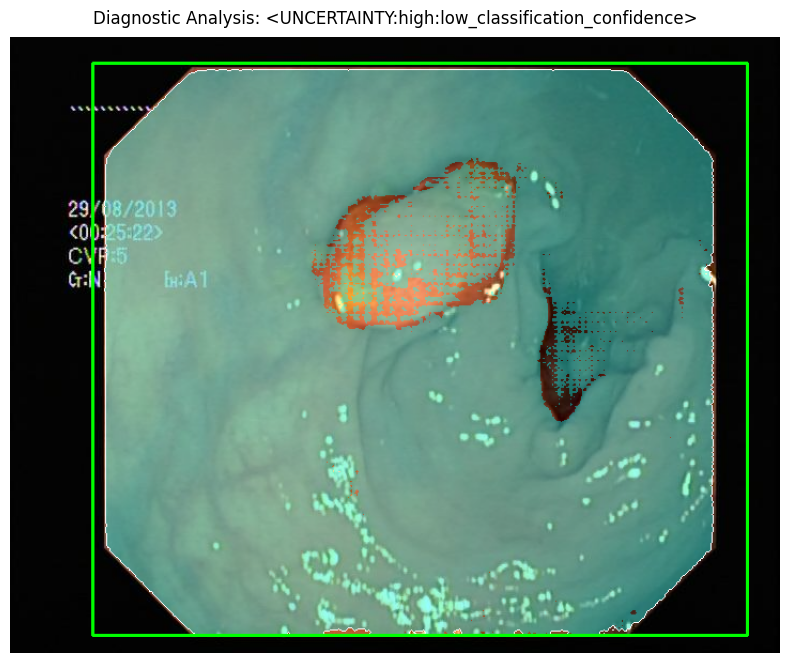

✔ Visualization rendered and saved as diagnostic_overlay.png


In [ ]:
import matplotlib.pyplot as plt
import cv2

# =========================
# 6. VISUALIZATION OVERLAY
# =========================
def generate_medical_overlay(orig_np, bboxes, seg_mask):
    """
    Applies professional-grade clinical overlays:
    - Cyan semi-transparent mask for segmentation.
    - Green bounding boxes for detections.
    """
    # Create a copy to avoid modifying the original array
    vis_img = orig_np.copy()

    # 1. Apply Segmentation Mask Overlay
    if seg_mask is not None and np.any(seg_mask):
        # Create a colored layer for the mask (Cyan: R=0, G=255, B=255)
        mask_overlay = vis_img.copy()
        mask_overlay[seg_mask] = [0, 255, 255]

        # Blend the color layer with the original (40% mask, 60% original)
        cv2.addWeighted(mask_overlay, 0.4, vis_img, 0.6, 0, vis_img)

        # Draw a thin white contour around the mask for visual "pop"
        contours, _ = cv2.findContours(
            seg_mask.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(vis_img, contours, -1, (255, 255, 255), 1)

    # 2. Apply Bounding Box Overlay
    for box in bboxes:
        # Cast coordinates to integers for OpenCV
        x1, y1, x2, y2 = map(int, box)
        # Draw Green box (R=0, G=255, B=0)
        cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return vis_img

# Generate the overlay using your existing variables
overlay_result = generate_medical_overlay(image_np, box_coords, mask)

# Display the result
plt.figure(figsize=(12, 8))
plt.imshow(overlay_result)
plt.axis('off')
plt.title(f"Diagnostic Analysis: {UNC_TOKEN}", fontsize=12, pad=10)
plt.show()

# Optional: Save for the paper draft
cv2.imwrite("diagnostic_overlay.png", cv2.cvtColor(overlay_result, cv2.COLOR_RGB2BGR))
print("✔ Visualization rendered and saved as diagnostic_overlay.png")

  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-7bo8wfss
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-7bo8wfss
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.1 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-cp312-cp312-linux_x86_64.whl size=183669 sha256=db5b059195c43cd0deafedf99ef18c60f6a8be9af9a1af54bf2c3a05369e3545
  Stored in directory: /tmp/pip-ephem-wheel-cache-hpb1_6y3/wheels/25/a3/8a/abd69dc6a6926b5e75c24810afac36c7b49b5c0f8a100147d6
  Created wheel for iopath: filename=iopath-0.1.10-py3-no

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

REPORT:
Based on the image provided, the final diagnosis is:

- Nematode worm (roundworm)

The image shows a roundworm, which is a type of nematode worm.


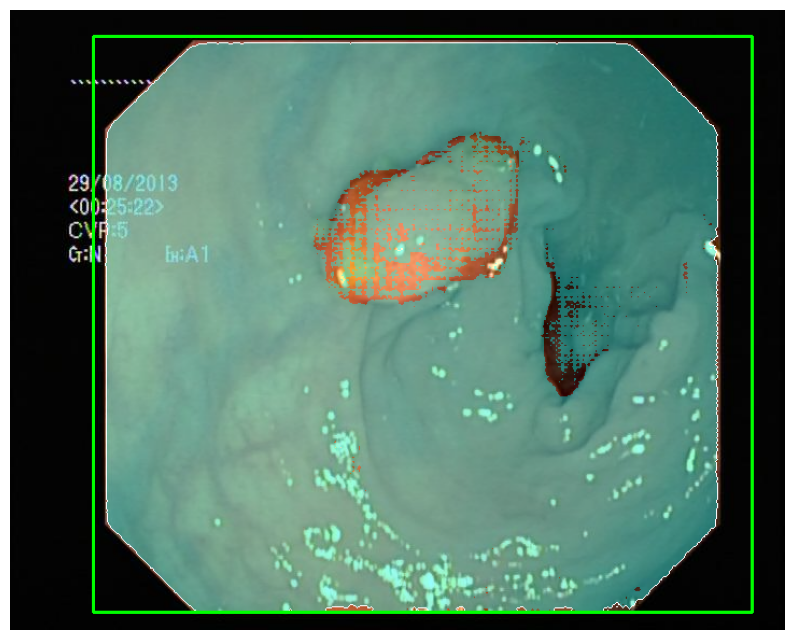

In [ ]:
# =========================
# 1. INSTALL & RESTART (If needed)
# =========================
!pip install -U transformers accelerate ultralytics
!pip install git+https://github.com/facebookresearch/sam2.git

import torch
import numpy as np
import cv2
import gc
from PIL import Image
import matplotlib.pyplot as plt

# Using specific Qwen2VL classes to ensure compatibility
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    ViTImageProcessor,
    ViTForImageClassification,
    Sam2Processor,
    Sam2Model
)
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# 2. LOAD MODELS (FP16 TO AVOID RECURSION)
# =========================
# We use 2B-Instruct in FP16. It fits in T4 VRAM and avoids bitsandbytes hooks.
vlm_id = "Qwen/Qwen2-VL-2B-Instruct"
vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    vlm_id, torch_dtype=torch.float16, device_map="auto"
)
vlm_processor = AutoProcessor.from_pretrained(vlm_id)

# Perception Suite
vit_proc = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit_model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224").to(device)
yolo_model = YOLO("yolov8n.pt")
sam_proc = Sam2Processor.from_pretrained("facebook/sam2-hiera-tiny")
sam_model = Sam2Model.from_pretrained("facebook/sam2-hiera-tiny").to(device)

# =========================
# 3. COORDINATE UTILITIES
# =========================
def get_polygon_coords(mask_bool, epsilon_factor=0.003):
    """Simplified polygon vertices for 'Full Mask Coordinates' token."""
    contours, _ = cv2.findContours(mask_bool.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for cnt in contours:
        epsilon = epsilon_factor * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        polys.append(approx.reshape(-1, 2).tolist())
    return polys

# =========================
# 4. ORCHESTRATION PIPELINE
# =========================
def run_clinical_pipeline(img_path):
    raw_img = Image.open(img_path).convert("RGB")
    img_np = np.array(raw_img)

    # Classification
    v_in = vit_proc(images=raw_img, return_tensors="pt").to(device)
    with torch.no_grad():
        v_out = vit_model(**v_in)
    label = vit_model.config.id2label[v_out.logits.argmax().item()]
    conf = torch.softmax(v_out.logits, dim=-1).max().item()
    CLS_TOKEN = f"<CLS:{label}:{conf:.2f}>"

    # Detection (BOX COORDS)
    y_res = yolo_model(img_np, verbose=False)[0]
    boxes = y_res.boxes.xyxy.cpu().numpy().astype(int).tolist() if y_res.boxes else []
    BOX_TOKEN = f"<BOX:{len(boxes)}:{boxes}>"

    # Segmentation (MASK COORDS)
    if not boxes:
        mask = np.zeros(img_np.shape[:2], dtype=bool)
        MASK_TOKEN = "<MASK:0:[]>"
    else:
        m_list = []
        for b in boxes:
            s_in = sam_proc(images=raw_img, input_boxes=[[b]], return_tensors="pt").to(device)
            with torch.no_grad():
                s_out = sam_model(**s_in)
            pm = sam_proc.post_process_masks(s_out.pred_masks, original_sizes=s_in['original_sizes'])
            m_list.append(pm[0][0][0].cpu().numpy())
        mask = np.logical_or.reduce(m_list)
        MASK_TOKEN = f"<MASK:{ (mask.sum()/mask.size)*100 :.2f}:{get_polygon_coords(mask)}>"

    # Reasoning
    prompt = f"Medical Image Analysis.\nTokens:\n{CLS_TOKEN}\n{BOX_TOKEN}\n{MASK_TOKEN}\n\nFinal Diagnosis:"

    messages = [{"role": "user", "content": [{"type": "image", "image": img_path}, {"type": "text", "text": prompt}]}]
    text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Qwen2VL specific input processing
    inputs = vlm_processor(text=[text], images=[raw_img], padding=True, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = vlm_model.generate(**inputs, max_new_tokens=128)

    # Trim input from output
    generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    response = vlm_processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

    return response, boxes, mask, img_np

# =========================
# 5. VISUALIZATION
# =========================
def show_clinical_overlay(img, bboxes, mask):
    plt.figure(figsize=(10, 10))
    vis = img.copy()
    if np.any(mask):
        overlay = vis.copy()
        overlay[mask] = [0, 255, 255] # Cyan highlight
        cv2.addWeighted(overlay, 0.4, vis, 0.6, 0, vis)
        cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, cnts, -1, (255, 255, 255), 1)
    for b in bboxes:
        cv2.rectangle(vis, (b[0], b[1]), (b[2], b[3]), (0, 255, 0), 2)
    plt.imshow(vis)
    plt.axis('off')
    plt.show()

# Execution
try:
    report, b_coords, f_mask, image = run_clinical_pipeline("/content/image.jpg")
    print(f"REPORT:\n{report}")
    show_clinical_overlay(image, b_coords, f_mask)
except Exception as e:
    print(f"Pipeline Error: {e}")

In [ ]:
!pip install --upgrade transformers

  Using cached transformers-5.4.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.4.0-py3-none-any.whl (10.1 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 5.3.0
    Uninstalling transformers-5.3.0:
      Successfully uninstalled transformers-5.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.3.7 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.3.0,>=4.51.3, but you have transformers 5.4.0 which is incompatible.
unsloth 2026.3.18 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.0,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.3.0,>=4.51.3, but you have transformers 5.4.0 which is incompatible.


Metrics

In [ ]:
!pip -q install -U transformers accelerate datasets timm albumentations opencv-python pycocotools peft
!pip -q install git+https://github.com/facebookresearch/sam2.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.2 MB/s eta 0:00:00
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user


In [ ]:
import os
import gc
import math
import random
import numpy as np
import cv2
from PIL import Image
from dataclasses import dataclass
from typing import List, Dict, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import Sam2Processor, Sam2Model
from peft import LoraConfig, get_peft_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)